In [1]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

file_path = "movies.csv"
df = pd.read_csv(file_path, encoding="latin1")

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/4.4 MB ? eta -:--:--
     -- ------------------------------------- 0.3/4.4 MB ? eta -:--:--
     --------- ------------------------------ 1.0/4.4 MB 3.0 MB/s eta 0:00:02
     ----------------------- ---------------- 2.6/4.4 MB 4.9 MB/s eta 0:00:01
     ----------------------------------- ---- 3.9/4.4 MB 5.3 MB/s eta 0:00:01
     ---------------------------------------- 4.4/4.4 MB 5.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to 

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      + meson setup C:\Users\garci\AppData\Local\Temp\pip-install-zf941hwb\pandas_7b431d5f7e834d9fa2741d54bafd5a84 C:\Users\garci\AppData\Local\Temp\pip-install-zf941hwb\pandas_7b431d5f7e834d9fa2741d54bafd5a84\.mesonpy-b5ofjz7t\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\garci\AppData\Local\Temp\pip-install-zf941hwb\pandas_7b431d5f7e834d9fa2741d54bafd5a84\.mesonpy-b5ofjz7t\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\garci\AppData\Local\Temp\pip-install-zf941hwb\pandas_7b431d5f7e834d9fa2741d54bafd5a84
      Build dir: C:\Users\garci\AppData\Local\Temp\pip-install-zf941hwb\pandas_7b431d5f7e834d9fa2741d54bafd5a84\.mesonpy-b5ofjz7t\build
      Build type: native build
      Project name: pandas
      Project version: 2.2.3
    

ModuleNotFoundError: No module named 'pandas'

## **1. Exploración rápida del dataset**

In [196]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

Dimensiones del dataset: 10000 filas, 27 columnas


In [166]:
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   budget                     10000 non-null  int64  
 2   genres                     9947 non-null   object 
 3   homePage                   4193 non-null   object 
 4   productionCompany          9543 non-null   object 
 5   productionCompanyCountry   8720 non-null   object 
 6   productionCountry          9767 non-null   object 
 7   revenue                    10000 non-null  float64
 8   runtime                    10000 non-null  int64  
 9   video                      9514 non-null   object 
 10  director                   9926 non-null   object 
 11  actors                     9920 non-null   object 
 12  actorsPopularity           9913 non-null   object 
 13  actorsCharact

In [167]:
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())


Estadísticas descriptivas de las variables numéricas:
                  id        budget       revenue       runtime    popularity  \
count   10000.000000  1.000000e+04  1.000000e+04  10000.000000  10000.000000   
mean   249876.829300  1.855163e+07  5.673793e+07    100.268100     51.393907   
std    257380.109004  3.662669e+07  1.495854e+08     27.777829    216.729552   
min         5.000000  0.000000e+00  0.000000e+00      0.000000      4.258000   
25%     12286.500000  0.000000e+00  0.000000e+00     90.000000     14.577750   
50%    152558.000000  5.000000e+05  1.631245e+05    100.000000     21.905500   
75%    452021.750000  2.000000e+07  4.479661e+07    113.000000     40.654000   
max    922260.000000  3.800000e+08  2.847246e+09    750.000000  11474.647000   

            voteAvg     voteCount  genresAmount  productionCoAmount  \
count  10000.000000  10000.000000  10000.000000        10000.000000   
mean       6.483490   1342.381800      2.596500            3.171400   
std        

In [168]:
# Calcular el porcentaje de valores nulos
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Filtrar solo las columnas con valores nulos
missing_percentage = missing_percentage[missing_percentage > 0]

print("\nPorcentaje de valores nulos en el dataset:")
print(missing_percentage)


Porcentaje de valores nulos en el dataset:
genres                       0.53
homePage                    58.07
productionCompany            4.57
productionCompanyCountry    12.80
productionCountry            2.33
video                        4.86
director                     0.74
actors                       0.80
actorsPopularity             0.87
actorsCharacter              0.47
dtype: float64


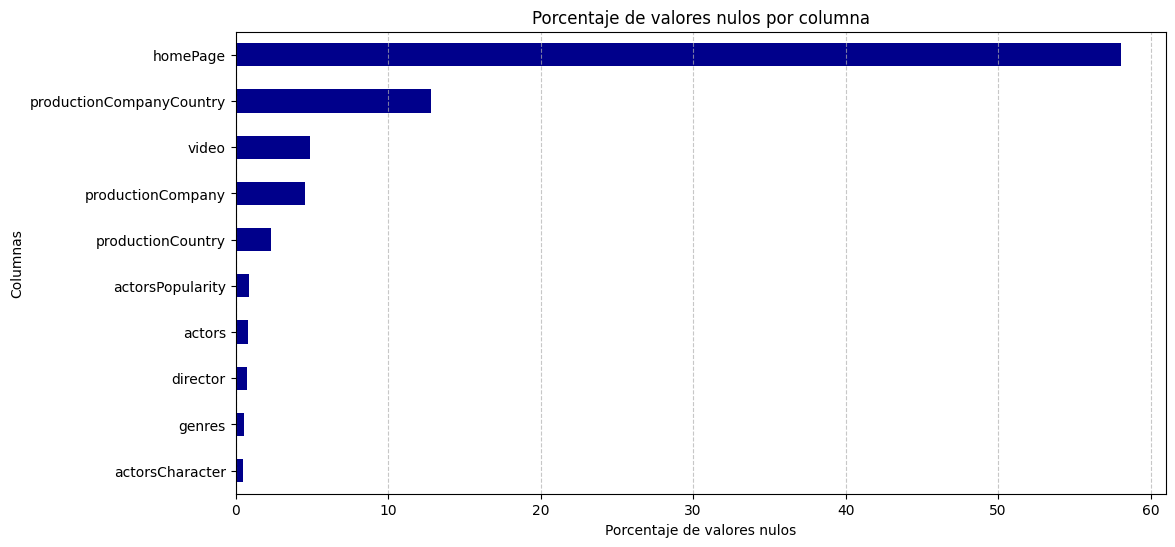

In [169]:
plt.figure(figsize=(12, 6))
missing_percentage.sort_values().plot(kind='barh', color='darkblue')

plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Columnas")
plt.title("Porcentaje de valores nulos por columna")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [170]:
# calcular el promedio de la popularidad de actores por película

def calcular_promedio_popularidad(val):
    if isinstance(val, str):  
        valores = [float(i) for i in val.strip('|').split('|') if i.replace('.', '', 1).isdigit()]  
        return np.mean(valores) if valores else np.nan  
    return np.nan  

df['actorsPopularity'] = df['actorsPopularity'].apply(calcular_promedio_popularidad)

print(df['actorsPopularity'].head(10))  
print("Valores únicos en 'actorsPopularity':", df['actorsPopularity'].nunique())

0    11.580640
1     6.476200
2     2.135924
3     8.139208
4     3.654921
5     4.824250
6     1.434987
7     4.962828
8     2.956991
9     1.533375
Name: actorsPopularity, dtype: float64
Valores únicos en 'actorsPopularity': 9782


## **2. Clasificación de las variables del dataset**

In [171]:
df['castWomenAmount'] = pd.to_numeric(df['castWomenAmount'], errors='coerce').astype('Int64')
df['castMenAmount'] = pd.to_numeric(df['castMenAmount'], errors='coerce').astype('Int64')

qualitative_nominal = []  
qualitative_ordinal = [] 
quantitative_continuous = []  
quantitative_discrete = [] 


for column in df.columns:
    if df[column].dtype == 'object':  # Variables categóricas (texto)
        qualitative_nominal.append(column)
    elif df[column].dtype in ['int64', 'Int64', 'float64']:  # Variables numéricas
        unique_values = df[column].nunique()
        if unique_values < 10:  # Se considera ordinal si tiene pocos valores únicos
            qualitative_ordinal.append(column)
        elif df[column].dtype in ['int64', 'Int64']:  # Variables discretas (enteros)
            quantitative_discrete.append(column)
        else:  # Variables continuas (decimales)
            quantitative_continuous.append(column)


print(f"Cualitativas nominales ({len(qualitative_nominal)}): {qualitative_nominal}")
print(f"Cualitativas ordinales ({len(qualitative_ordinal)}): {qualitative_ordinal}")
print(f"Cuantitativas continuas ({len(quantitative_continuous)}): {quantitative_continuous}")
print(f"Cuantitativas discretas ({len(quantitative_discrete)}): {quantitative_discrete}")


Cualitativas nominales (13): ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 'originalTitle', 'title', 'originalLanguage', 'releaseDate']
Cualitativas ordinales (0): []
Cuantitativas continuas (4): ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
Cuantitativas discretas (10): ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 'castWomenAmount', 'castMenAmount']


## **3.1 Las variables cuantitativas siguen una distribución normal?**

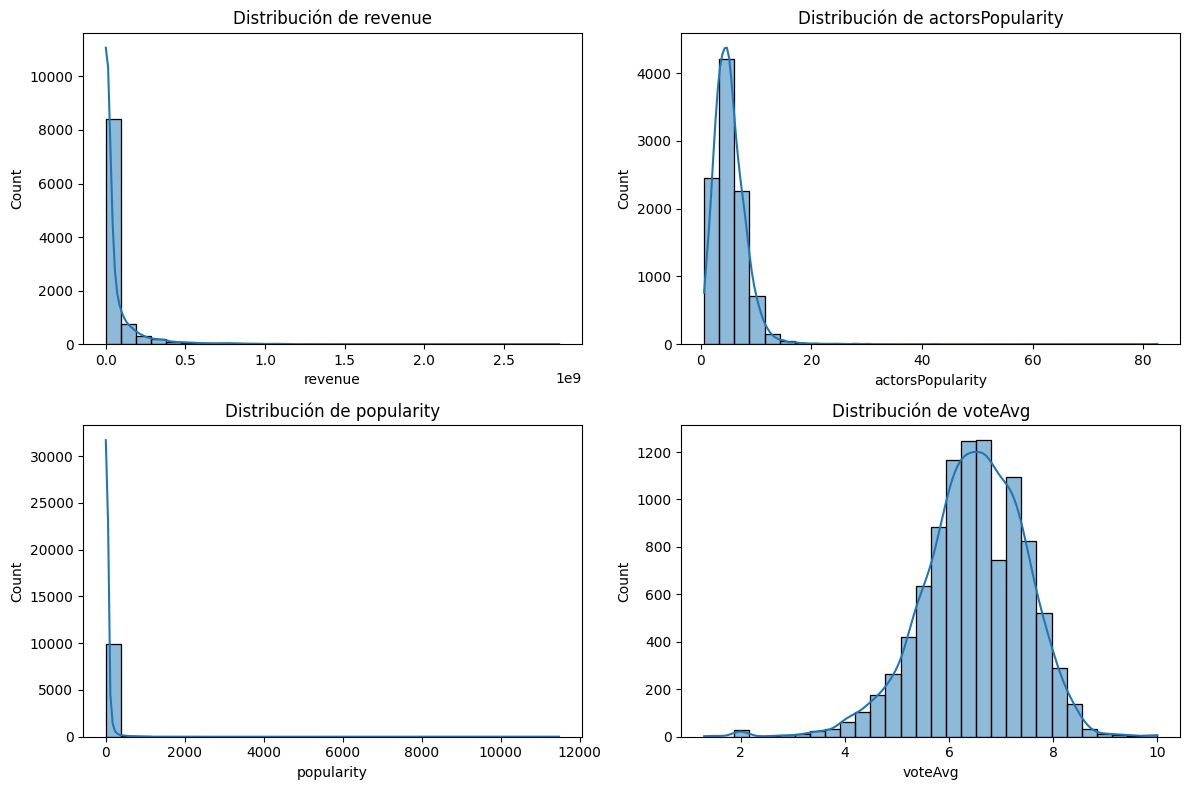

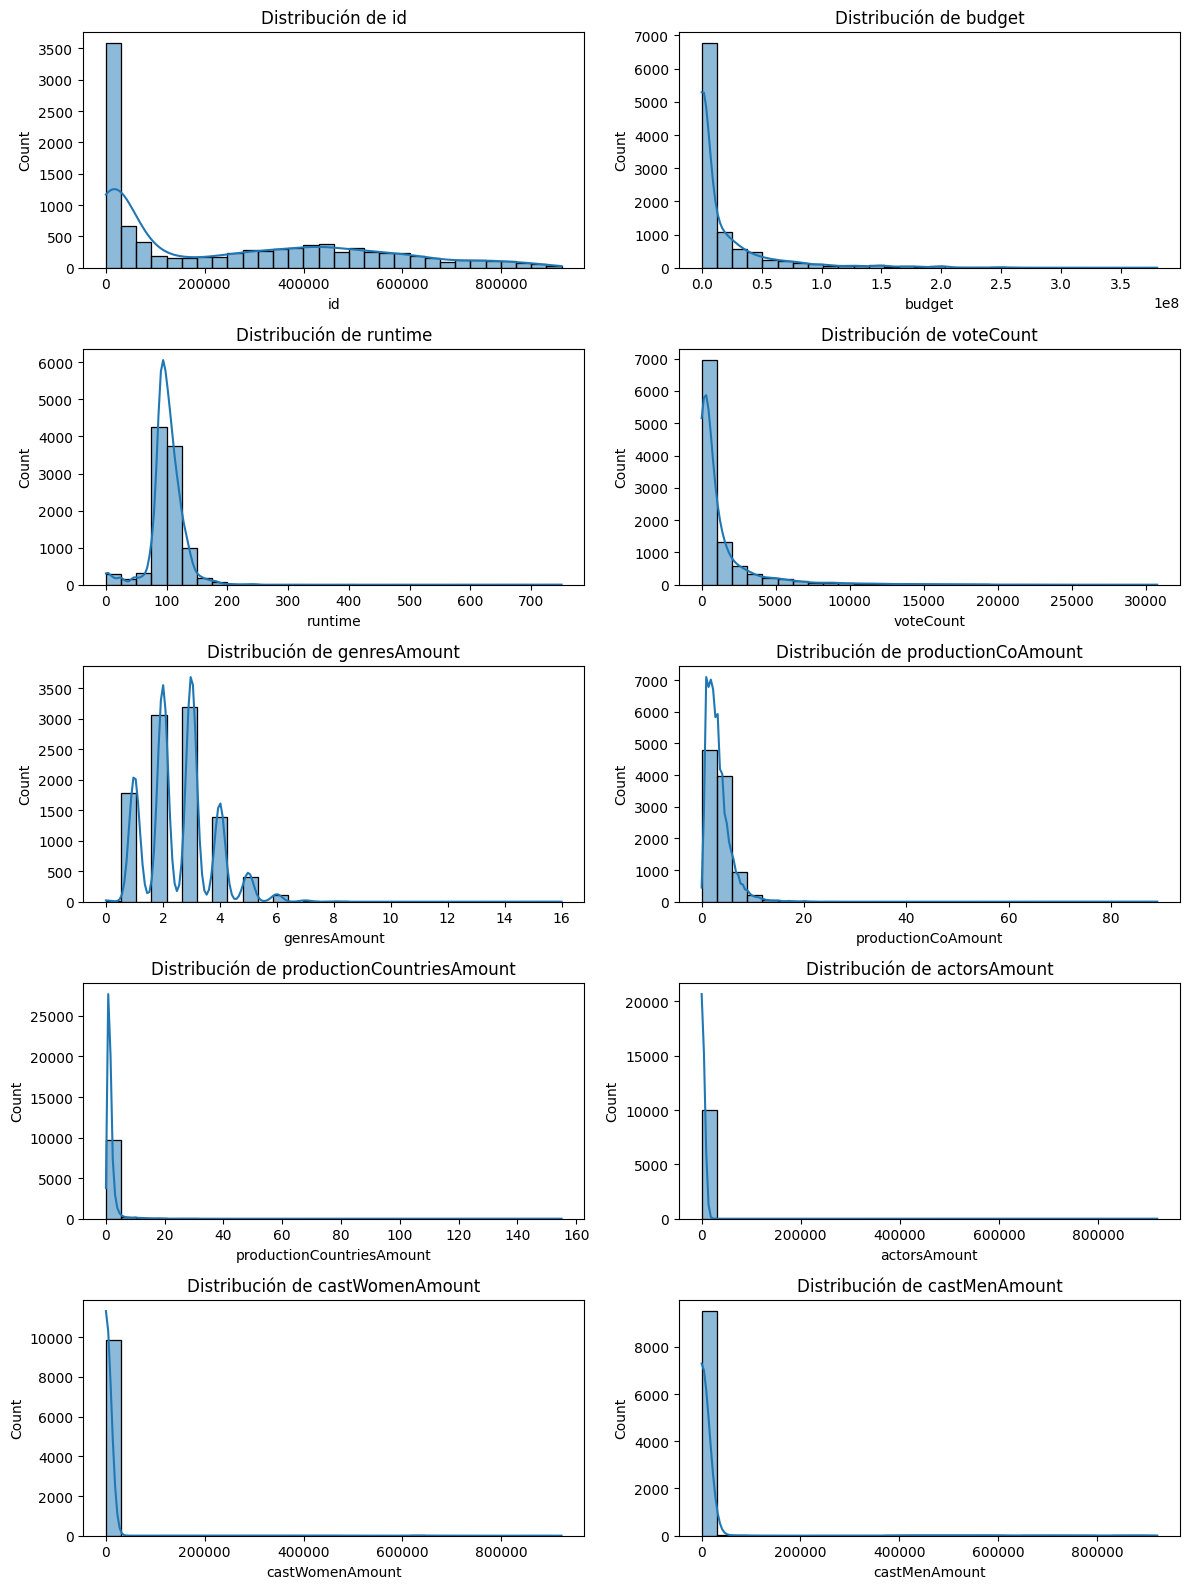

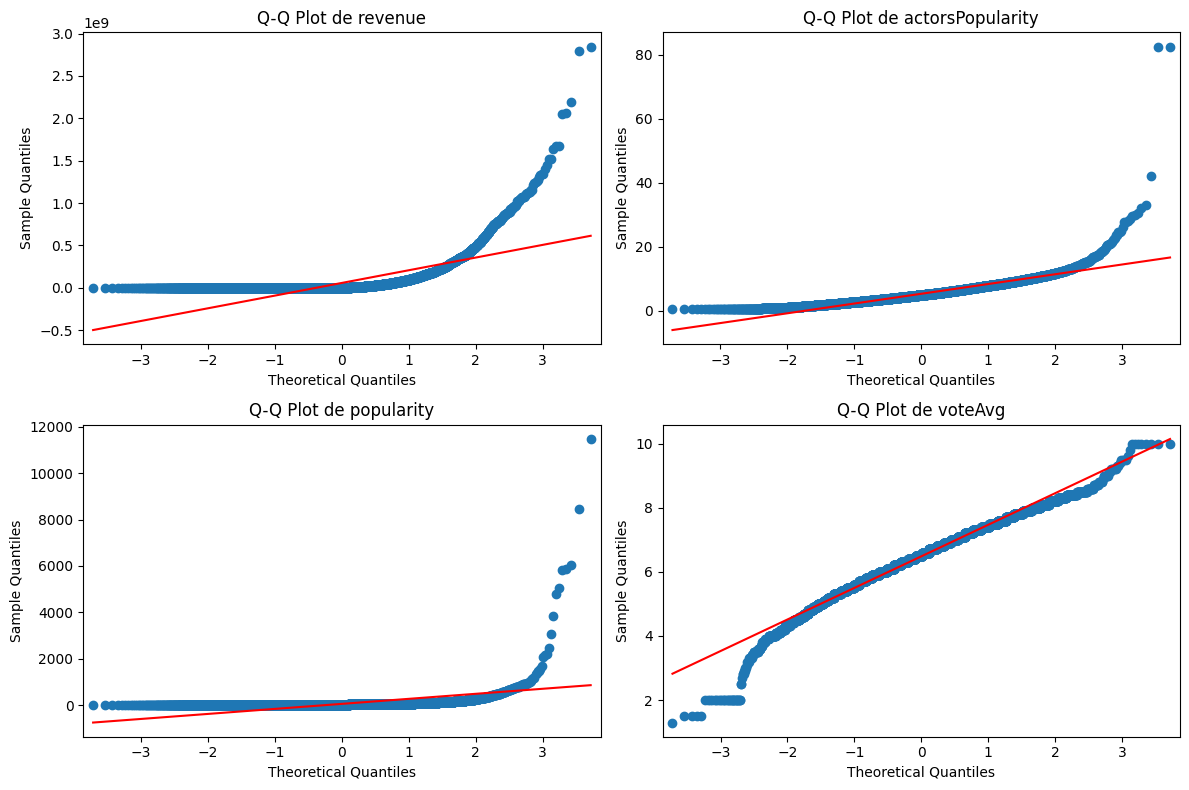

Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:


,Statistic,P-Value,Normal
revenue,0.352232,0.0,False
actorsPopularity,0.074546,0.0,False
popularity,0.417335,0.0,False
voteAvg,0.04591,0.0,False



Resultados de la prueba de Kolmogorov-Smirnov para variables discretas:


,Statistic,P-Value,Normal
id,0.200786,0.0,False
budget,0.306251,0.0,False
runtime,0.14408,0.0,False
voteCount,0.300445,0.0,False
genresAmount,0.183598,0.0,False
productionCoAmount,0.200403,0.0,False
productionCountriesAmount,0.392653,0.0,False
actorsAmount,0.516689,0.0,False
castWomenAmount,0.52831,0.0,False
castMenAmount,0.52814,0.0,False


In [172]:
quantitative_continuous_vars = ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
quantitative_discrete_vars = ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 
                              'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 
                              'castWomenAmount', 'castMenAmount']

for var in quantitative_continuous_vars + quantitative_discrete_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Aplicar la prueba de Kolmogorov-Smirnov para normalidad
def ks_test(variable):
    clean_data = df[variable].dropna()
    if len(clean_data) >= 3:
        stat, p_value = stats.kstest(clean_data, 'norm', args=(clean_data.mean(), clean_data.std()))
        return {'Statistic': stat, 'P-Value': p_value, 'Normal': p_value > 0.05}
    else:
        return {'Statistic': np.nan, 'P-Value': np.nan, 'Normal': np.nan}

normality_results_continuous = {var: ks_test(var) for var in quantitative_continuous_vars}
normality_results_discrete = {var: ks_test(var) for var in quantitative_discrete_vars}

normality_df_continuous = pd.DataFrame(normality_results_continuous).T
normality_df_discrete = pd.DataFrame(normality_results_discrete).T

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.flatten()
for i, var in enumerate(quantitative_discrete_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sm.qqplot(df[var].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot de {var}')
plt.tight_layout()
plt.show()


print("Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:")
display(normality_df_continuous)

print("\nResultados de la prueba de Kolmogorov-Smirnov para variables discretas:")
display(normality_df_discrete)



## Prueba para verificar sesgos

In [173]:
skewness_kurtosis = df[quantitative_continuous_vars + quantitative_discrete_vars].skew().to_frame(name="Skewness")
skewness_kurtosis["Kurtosis"] = df[quantitative_continuous_vars + quantitative_discrete_vars].kurtosis()
display(skewness_kurtosis)


,Skewness,Kurtosis
revenue,5.919857,55.932018
actorsPopularity,4.783214,90.687716
popularity,30.378934,1226.192397
voteAvg,-0.5778,1.487066
id,0.681957,-0.790283
budget,3.244864,13.218236
runtime,0.97199,35.554741
voteCount,4.147104,22.782155
genresAmount,0.691445,2.107499
productionCoAmount,5.988578,140.372931


## **3.2 Tabla de frecuencias de las variables cualitativas**

In [174]:
qualitative_nominal_vars = ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 
                            'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 
                            'originalTitle', 'title', 'originalLanguage', 'releaseDate']

def count_frequencies(column):
    all_values = df[column].dropna().astype(str).str.split('|').explode()  # Dividir y expandir
    all_values = all_values.str.strip()  # Eliminar espacios en blanco antes y después de cada valor
    all_values = all_values[all_values != ""]  # Eliminar valores vacíos resultantes
    return all_values.value_counts().reset_index().rename(columns={'index': column, column: 'Frecuencia'})


frequency_tables = {var: count_frequencies(var) for var in qualitative_nominal_vars}

for var, table in frequency_tables.items():
    print(f"\nTabla de Frecuencia para {var}:")
    display(table.head(10)) 


Tabla de Frecuencia para genres:


,Frecuencia,count
0,Drama,3789
1,Comedy,3018
2,Action,2632
3,Thriller,2565
4,Adventure,1769
5,Horror,1512
6,Animation,1460
7,Romance,1428
8,Family,1407
9,Fantasy,1284



Tabla de Frecuencia para homePage:


,Frecuencia,count
0,http://www.naruto-movie.com/,6
1,http://www.thehungergames.movie/,4
2,http://www.p3m.jp/,3
3,http://www.kungfupanda.com/,3
4,http://kizumonogatari-usa.com/,3
5,http://www.missionimpossible.com/,3
6,http://www.kungfupanda.com,3
7,http://www.transformersmovie.com/,3
8,http://initiald-movie.com/,3
9,http://wwws.warnerbros.co.jp/rurouni-kenshin/i...,3



Tabla de Frecuencia para productionCompany:


...

,Frecuencia,count
0,Pinocchio,4
1,Cinderella,4
2,Carrie,3
3,The Courier,3
4,Awake,3
5,Escape Room,3
6,Halloween,3
7,Porno,3
8,Godzilla,3
9,The Call,3



Tabla de Frecuencia para originalLanguage:


,Frecuencia,count
0,en,7772
1,ja,644
2,es,425
3,fr,271
4,ko,167
5,zh,119
6,it,100
7,de,84
8,cn,80
9,ru,67



Tabla de Frecuencia para releaseDate:


,Frecuencia,count
0,2021-10-08,15
1,2021-02-12,15
2,2021-10-01,14
3,2021-11-12,12
4,2019-11-08,11
5,2021-07-23,11
6,2020-10-02,11
7,2021-06-11,11
8,2019-05-24,11
9,2021-12-17,10


## **4. ¿Cuáles son las 10 películas que contaron con más presupuesto?**

In [175]:
top_budget_movies = df[['title', 'originalTitle', 'budget']].sort_values(by='budget', ascending=False).head(10).reset_index(drop=True)
print("Las 10 películas con mayor presupuesto:")
display(top_budget_movies)

Las 10 películas con mayor presupuesto:


,title,originalTitle,budget
0,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,380000000
1,Avengers: Age of Ultron,Avengers: Age of Ultron,365000000
2,Avengers: Endgame,Avengers: Endgame,356000000
3,Justice League,Justice League,300000000
4,Avengers: Infinity War,Avengers: Infinity War,300000000
5,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,300000000
6,Superman Returns,Superman Returns,270000000
7,The Lion King,The Lion King,260000000
8,Tangled,Tangled,260000000
9,Spider-Man 3,Spider-Man 3,258000000


## **5. ¿Cuáles son las 10 películas que más ingresos tuvieron?**

In [176]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

top_revenue_movies = df[['title', 'originalTitle', 'revenue']].sort_values(by='revenue', ascending=False).head(10).reset_index(drop=True)

print("Las 10 películas con mayores ingresos:")
display(top_revenue_movies)

Las 10 películas con mayores ingresos:


,title,originalTitle,revenue
0,Avatar,Avatar,2.847246e+09
1,Avengers: Endgame,Avengers: Endgame,2.797801e+09
2,Titanic,Titanic,2.187464e+09
3,Star Wars: The Force Awakens,Star Wars: The Force Awakens,2.068224e+09
4,Avengers: Infinity War,Avengers: Infinity War,2.046240e+09
5,Jurassic World,Jurassic World,1.671713e+09
6,The Lion King,The Lion King,1.667635e+09
7,Spider-Man: No Way Home,Spider-Man: No Way Home,1.631853e+09
8,The Avengers,The Avengers,1.518816e+09
9,Furious 7,Furious 7,1.515048e+09


## **6. ¿Cuál es la película que más votos tuvo?¿Cuál es la película que más votos tuvo?**

In [177]:
df['voteCount'] = pd.to_numeric(df['voteCount'], errors='coerce')

top_voted_movie = df[['title', 'originalTitle', 'voteCount']].sort_values(by='voteCount', ascending=False).head(1).reset_index(drop=True)

print("La película con más votos:")
display(top_voted_movie)

La película con más votos:


,title,originalTitle,voteCount
0,Inception,Inception,30788


## **7. ¿Cuál es la peor película de acuerdo a los votos de todos los usuarios?**

In [178]:
df['voteAvg'] = pd.to_numeric(df['voteAvg'], errors='coerce')

worst_movie = df[['title', 'voteAvg', 'voteCount']].sort_values(by='voteAvg', ascending=True).head(1).reset_index(drop=True)

print("La peor película según la calificación de los usuarios:")
display(worst_movie)

La peor película según la calificación de los usuarios:


,title,voteAvg,voteCount
0,DAKAICHI -I'm Being Harassed by the Sexiest Ma...,1.3,2


## **8. ¿Cuántas películas se hicieron en cada año? ¿En qué año se hicieron más películas? Haga un gráfico de barras.**

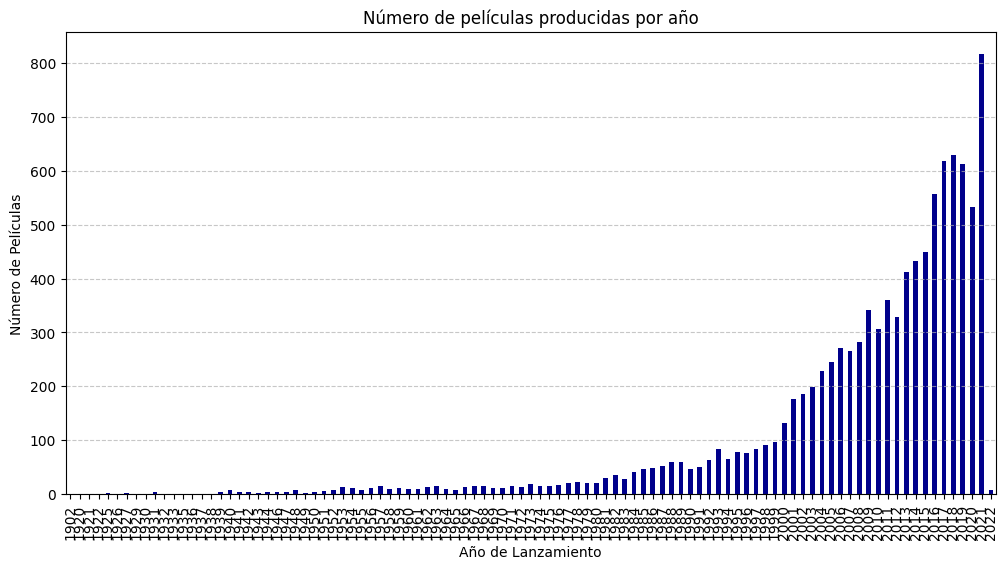

El año con más películas lanzadas fue: 2021 con 816 películas


In [179]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseYear'] = df['releaseDate'].dt.year

movies_per_year = df['releaseYear'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
movies_per_year.plot(kind='bar', color='darkblue')
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Número de Películas")
plt.title("Número de películas producidas por año")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

most_movies_year = movies_per_year.idxmax()
print(f"El año con más películas lanzadas fue: {most_movies_year} con {movies_per_year.max()} películas")

## **9. ¿Cuál es el género principal de las 20 películas más recientes? ¿Cuál es el género principal que predomina en el conjunto de datos? Represéntelo usando un gráfico. ¿A qué género principal pertenecen las películas más largas**

El género principal de las 20 películas más recientes es 'Comedy' con 6 películas.


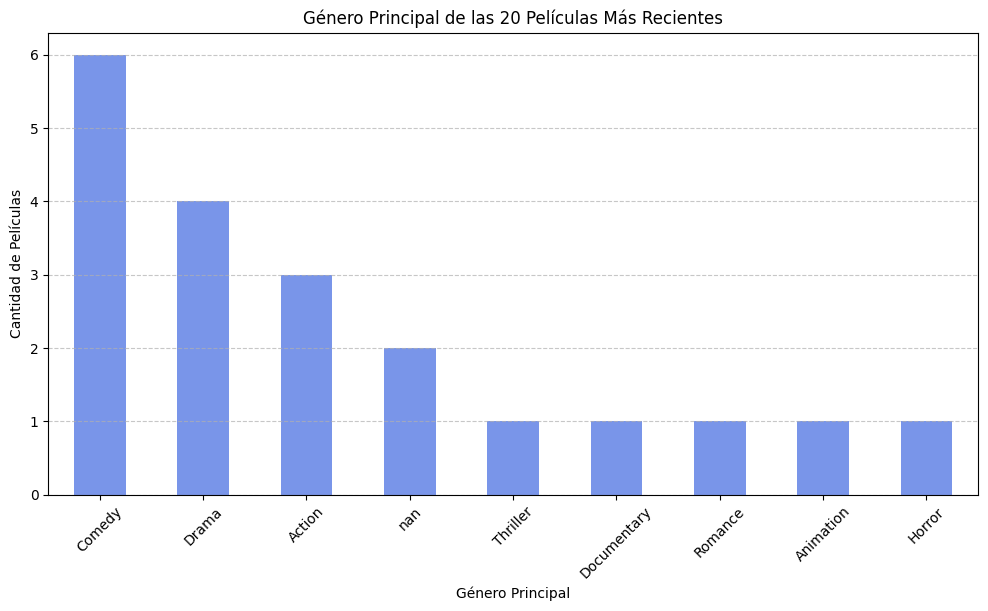

El género principal que predomina en el conjunto de datos es 'Drama' con 1803 películas.


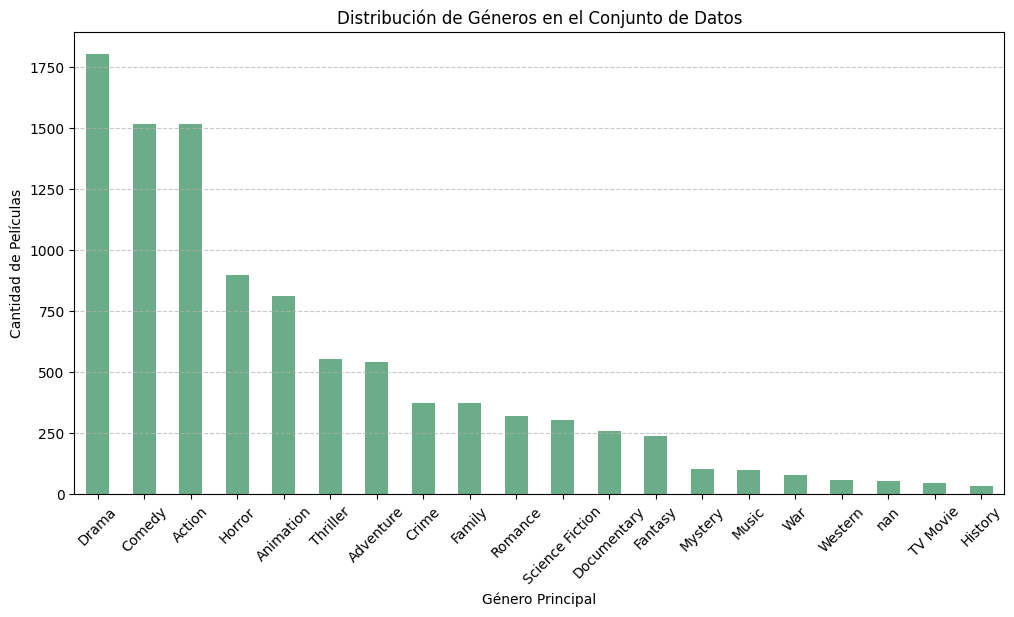

El género principal de las películas más largas es 'Drama' con 7 películas.


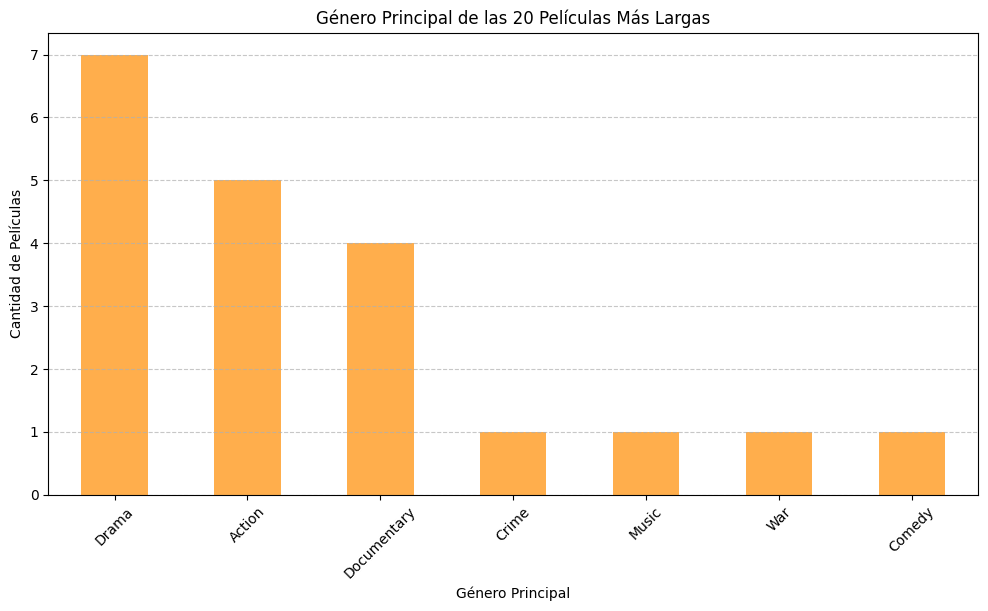

In [180]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['primaryGenre'] = df['genres'].astype(str).apply(lambda x: x.split('|')[0] if pd.notna(x) else 'Desconocido')

recent_movies = df.sort_values(by='releaseDate', ascending=False).head(20)
recent_genres = recent_movies['primaryGenre'].value_counts()
recent_genre_most_common = recent_genres.idxmax()
recent_genre_count = recent_genres.max()

top_genres = df['primaryGenre'].value_counts()
most_common_genre = top_genres.idxmax()
most_common_genre_count = top_genres.max()

longest_movies = df.sort_values(by='runtime', ascending=False).head(20)
longest_genres = longest_movies['primaryGenre'].value_counts()
longest_genre_most_common = longest_genres.idxmax()
longest_genre_count = longest_genres.max()

print(f"El género principal de las 20 películas más recientes es '{recent_genre_most_common}' con {recent_genre_count} películas.")
plt.figure(figsize=(12, 6))
recent_genres.plot(kind='bar', color='royalblue', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Género Principal de las 20 Películas Más Recientes")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"El género principal que predomina en el conjunto de datos es '{most_common_genre}' con {most_common_genre_count} películas.")
plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar', color='seagreen', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Distribución de Géneros en el Conjunto de Datos")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"El género principal de las películas más largas es '{longest_genre_most_common}' con {longest_genre_count} películas.")
plt.figure(figsize=(12, 6))
longest_genres.plot(kind='bar', color='darkorange', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Género Principal de las 20 Películas Más Largas")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **10. ¿Las películas de qué género principal obtuvieron mayores ganancias?**

El género principal con mayores ganancias promedio es 'Adventure' con una ganancia media de $110,498,311.03.


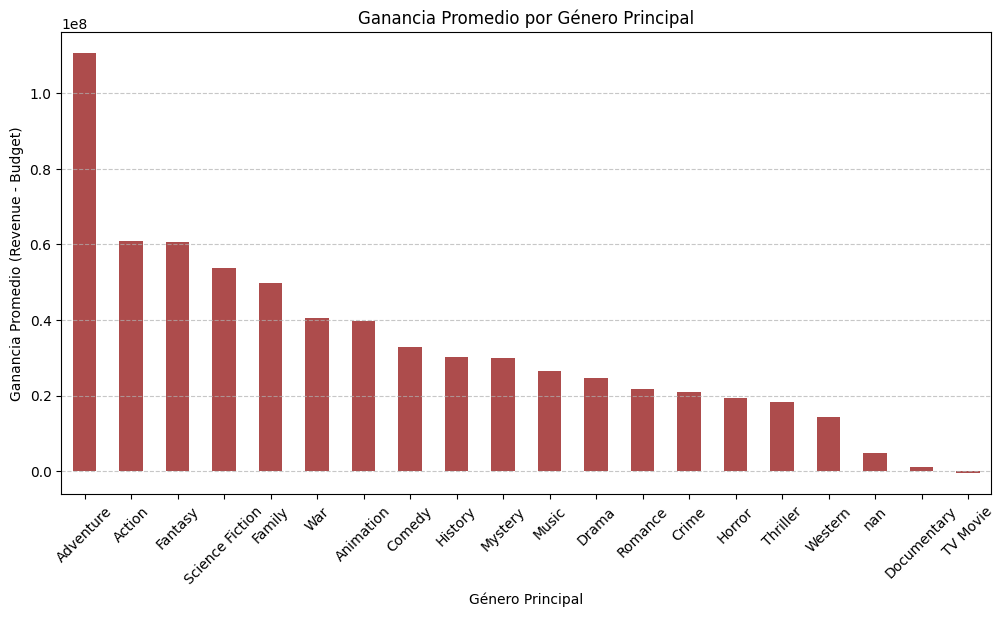

In [181]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['primaryGenre'] = df['genres'].astype(str).apply(lambda x: x.split('|')[0] if pd.notna(x) else 'Desconocido')
df['profit'] = df['revenue'] - df['budget']

genre_profits = df.groupby('primaryGenre')['profit'].mean().sort_values(ascending=False)

most_profitable_genre = genre_profits.idxmax()
highest_profit = genre_profits.max()

print(f"El género principal con mayores ganancias promedio es '{most_profitable_genre}' con una ganancia media de ${highest_profit:,.2f}.")

plt.figure(figsize=(12, 6))
genre_profits.plot(kind='bar', color='darkred', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Ganancia Promedio (Revenue - Budget)")
plt.title("Ganancia Promedio por Género Principal")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **11. ¿La cantidad de actores influye en los ingresos de las películas? ¿Se han hecho películas con más actores en los últimos años?**

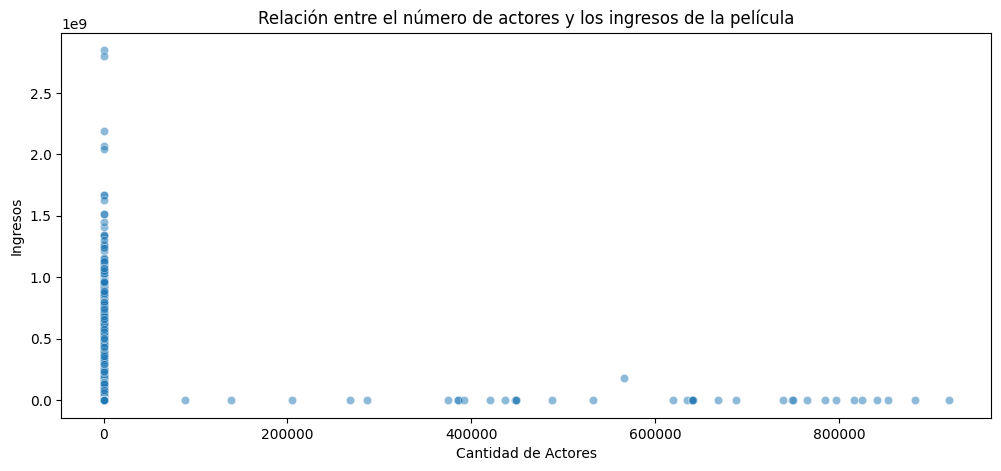

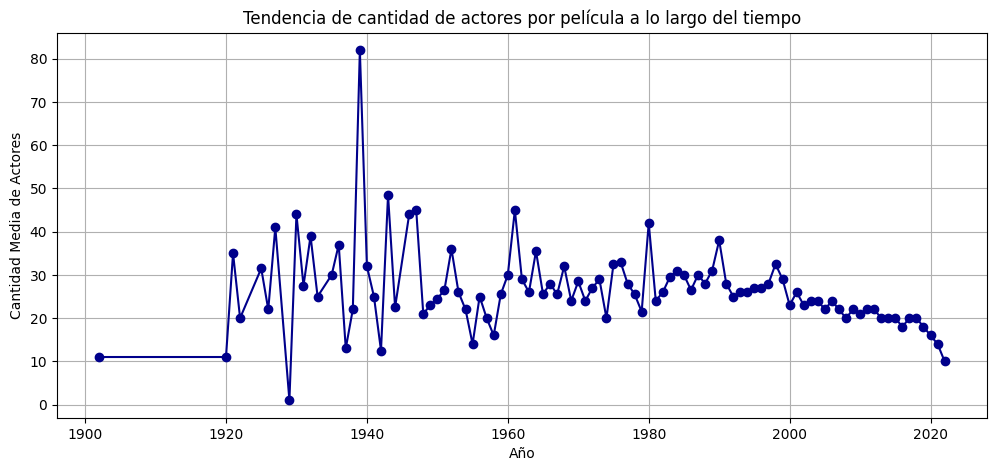

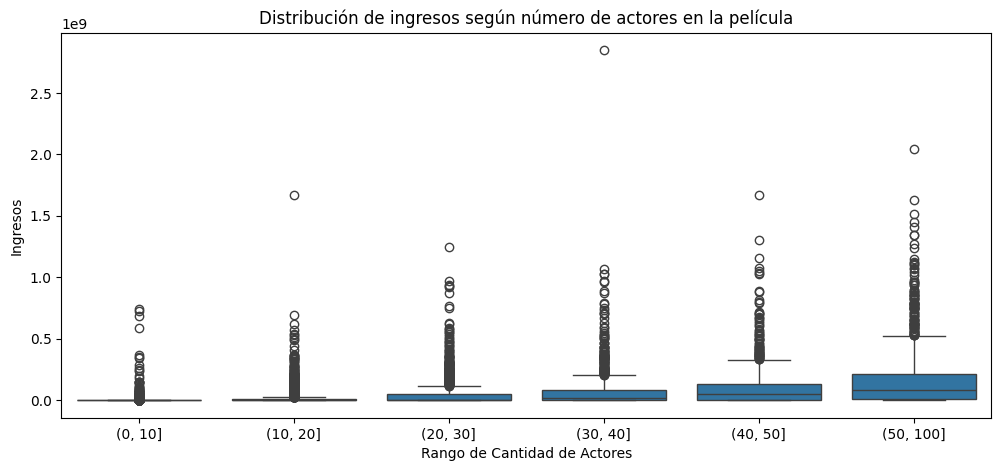

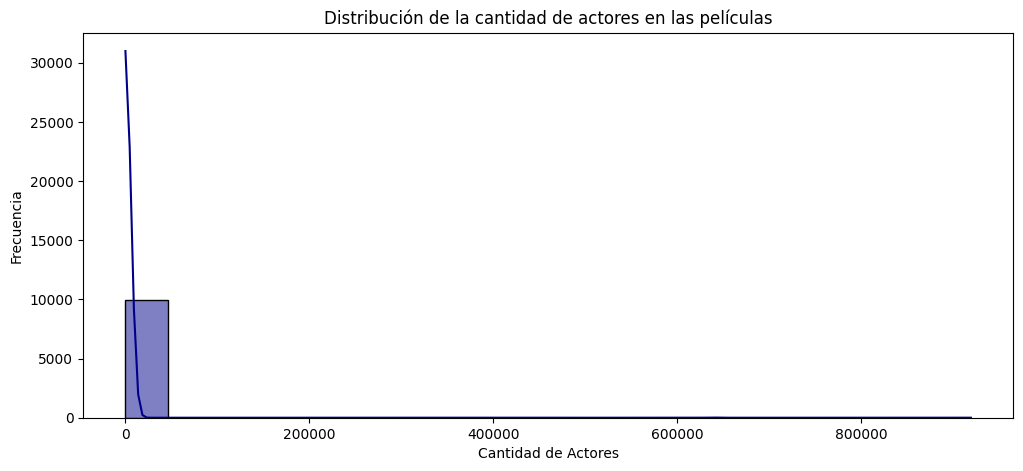

In [182]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['actorsAmount'], y=df['revenue'], alpha=0.5)
plt.xlabel("Cantidad de Actores")
plt.ylabel("Ingresos")
plt.title("Relación entre el número de actores y los ingresos de la película")
plt.show()

actors_per_year = df.groupby('releaseYear')['actorsAmount'].median()
plt.figure(figsize=(12, 5))
actors_per_year.plot(kind='line', marker='o', color='darkblue')
plt.xlabel("Año")
plt.ylabel("Cantidad Media de Actores")
plt.title("Tendencia de cantidad de actores por película a lo largo del tiempo")
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['actorsAmount'], bins=[0, 10, 20, 30, 40, 50, 100]), y=df['revenue'])
plt.xlabel("Rango de Cantidad de Actores")
plt.ylabel("Ingresos")
plt.title("Distribución de ingresos según número de actores en la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['actorsAmount'].dropna(), bins=20, kde=True, color='darkblue')
plt.xlabel("Cantidad de Actores")
plt.ylabel("Frecuencia")
plt.title("Distribución de la cantidad de actores en las películas")
plt.show()

## **12. ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas?**

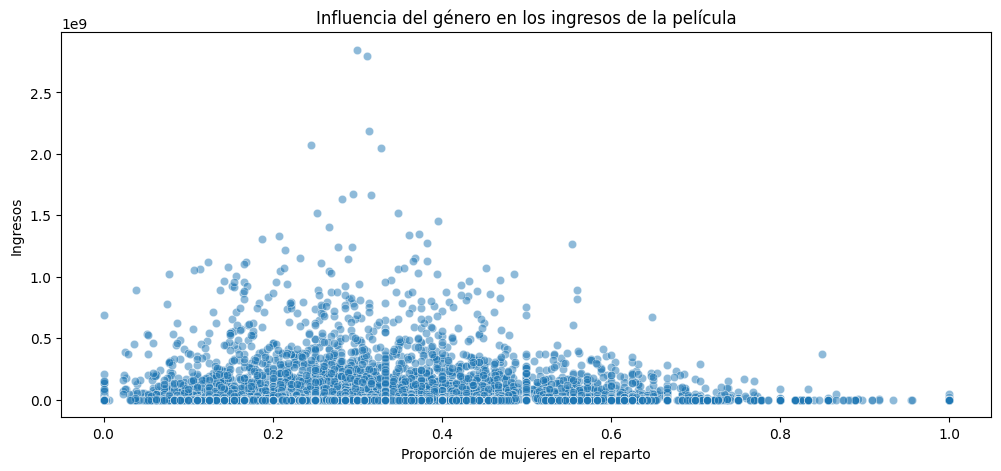

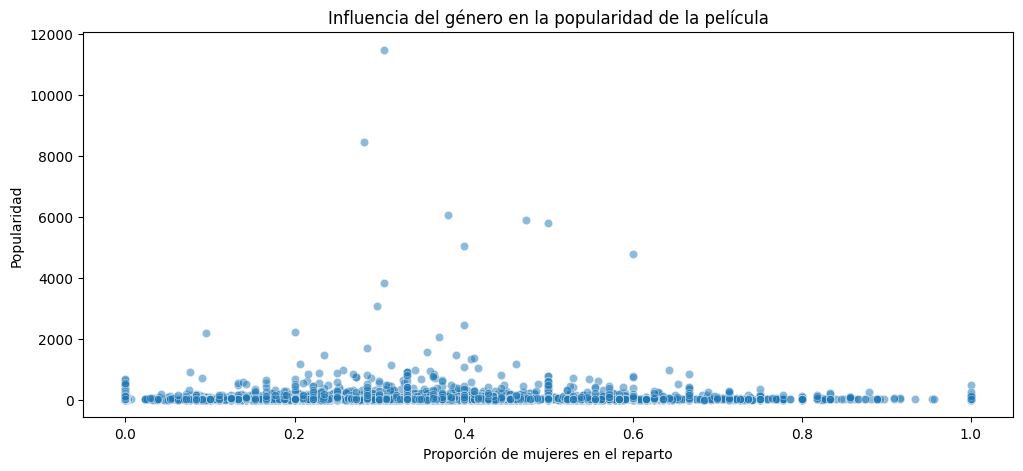

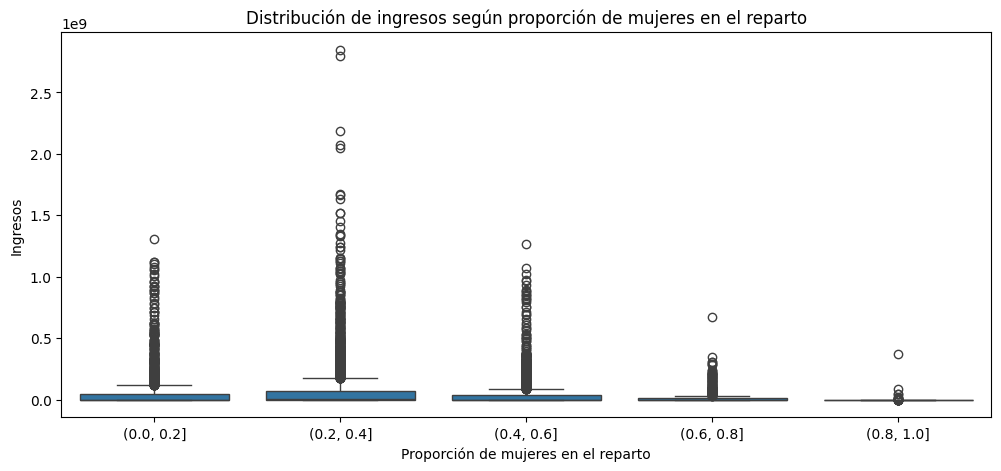

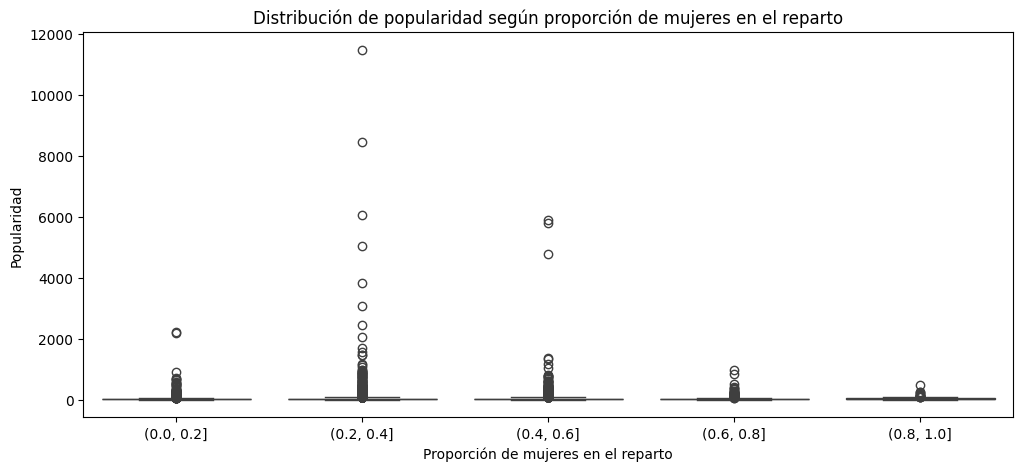

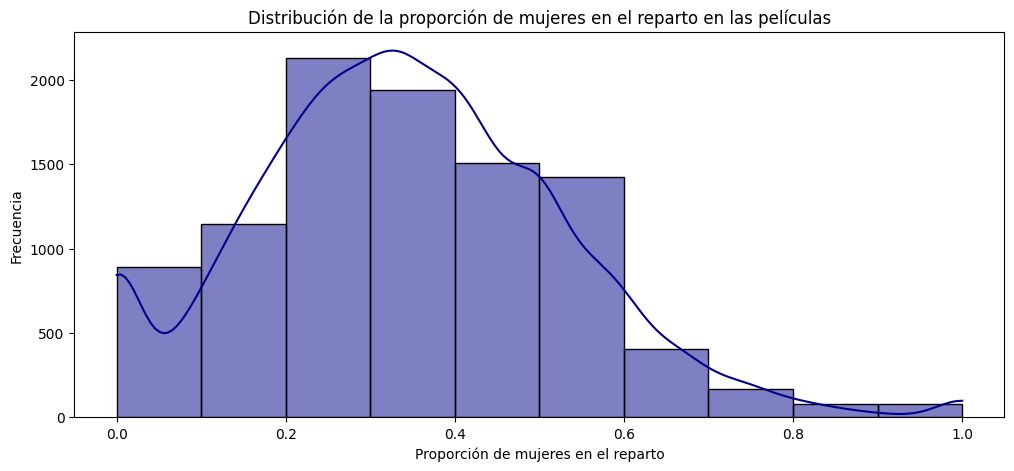

In [183]:
df['gender_ratio'] = df['castWomenAmount'] / (df['castWomenAmount'] + df['castMenAmount'])

plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['gender_ratio'], y=df['revenue'], alpha=0.5)
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Ingresos")
plt.title("Influencia del género en los ingresos de la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['gender_ratio'], y=df['popularity'], alpha=0.5)
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Popularidad")
plt.title("Influencia del género en la popularidad de la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['gender_ratio'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1]), y=df['revenue'])
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Ingresos")
plt.title("Distribución de ingresos según proporción de mujeres en el reparto")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['gender_ratio'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1]), y=df['popularity'])
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Popularidad")
plt.title("Distribución de popularidad según proporción de mujeres en el reparto")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['gender_ratio'].dropna(), bins=10, kde=True, color='darkblue')
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Frecuencia")
plt.title("Distribución de la proporción de mujeres en el reparto en las películas")
plt.show()

## **13. ¿Quiénes son los directores que hicieron las 20 películas mejor calificadas?**

In [184]:
top_rated_movies = df.sort_values(by='voteAvg', ascending=False).head(20)
directors_top_rated = top_rated_movies[['director', 'title', 'voteAvg']]
print("Directores de las 20 películas mejor calificadas:")
display(directors_top_rated)

Directores de las 20 películas mejor calificadas:


,director,title,voteAvg
9298,Laurent Bouzereau,Spirit of Vengeance: The Making of 'Ghost Rider',10.0
9733,Christin Baker,Christmas at the Ranch,10.0
9875,NaN,El Chavo Del Ocho: Lo Mejor De Don Ramon,10.0
9246,Rebecca Sugar,Steven Universe: The Movie: Behind the Curtain,10.0
9990,Miguel Angel Zavala,Los Vengadores Chiflados,10.0
8632,Thomas Coven,Hot Naked Sex & the City,10.0
9347,Kaku Arakawa,How Ponyo was Born ~Hayao Miyazaki's Thought P...,10.0
9084,Víctor Barba|Juan Olivares,Holidays,10.0
6750,NaN,Dragon Ball Kami BEST [Bonus DVD],9.8
6885,Dave Bullock|Troy Adomitis|Victor Cook,The Spectacular Spider-Man Attack of the Lizard,9.6


## **14. ¿Cómo se correlacionan los presupuestos con los ingresos? ¿Los altos presupuestos significan altos ingresos? Haga los gráficos que necesite, histograma, diagrama de dispersión.**

Coeficientes de Correlación entre Presupuesto e Ingresos:


,Métrica,Coeficiente de Correlación,P-Value
0,Pearson,0.718653,0.0
1,Spearman,0.682958,0.0


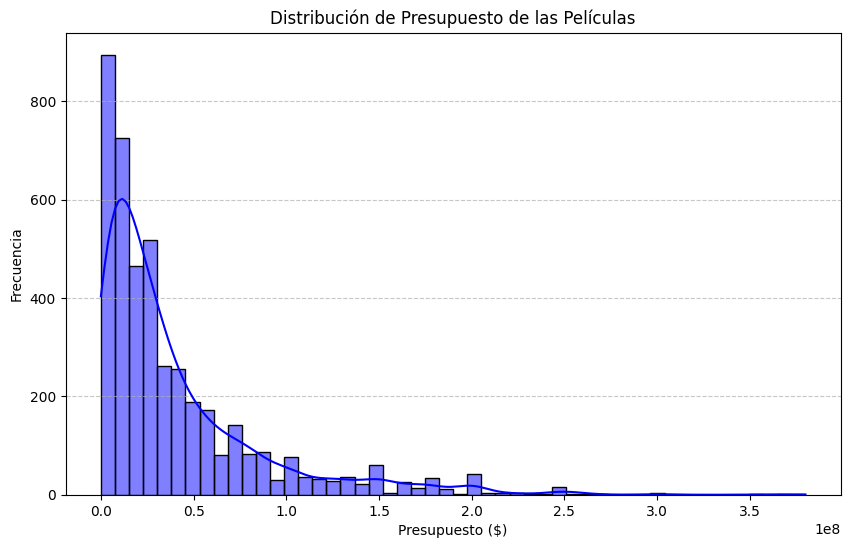

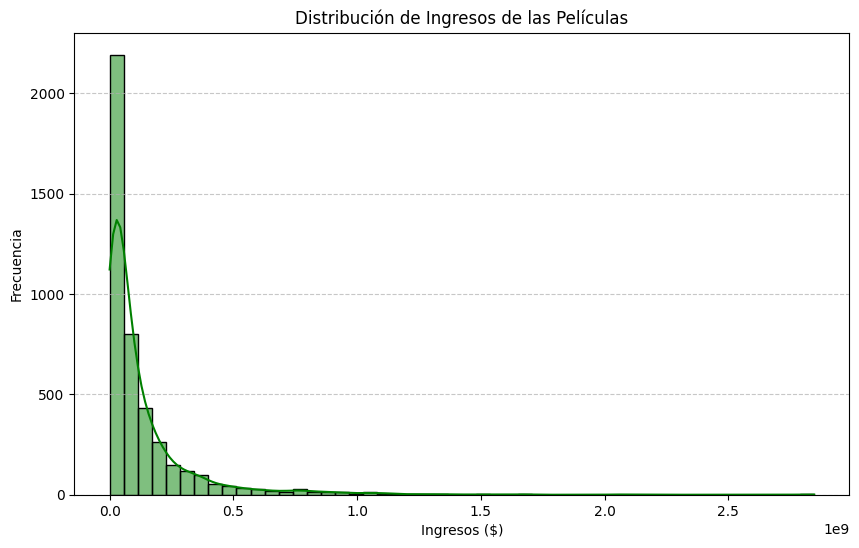

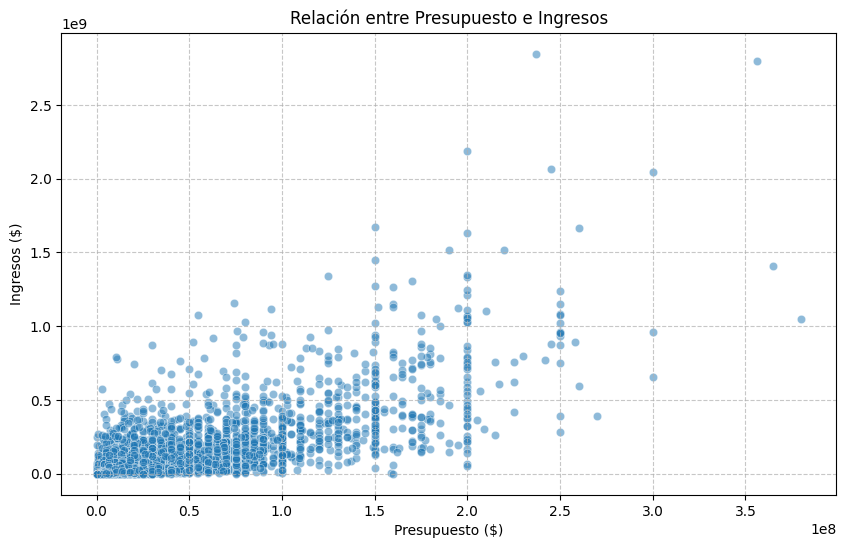

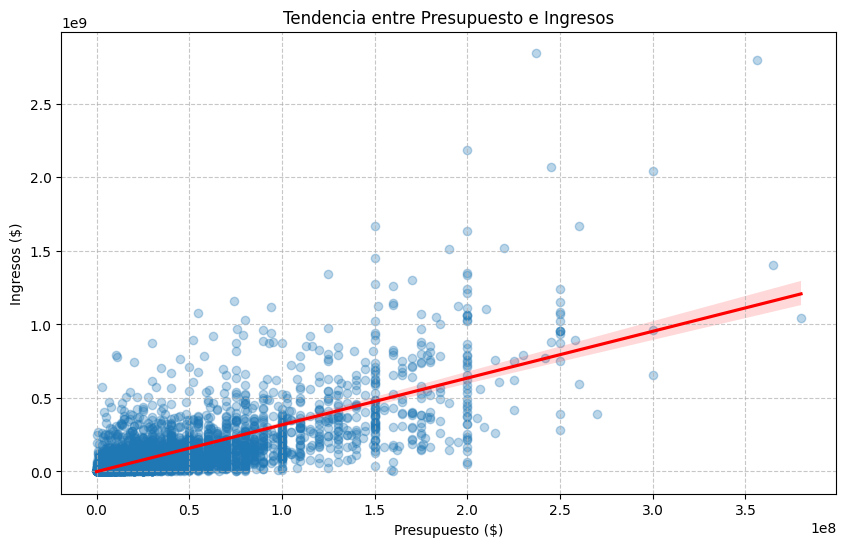

In [185]:
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

df_filtered = df[(df['budget'] > 0) & (df['revenue'] > 0)]  

pearson_corr, pearson_p = pearsonr(df_filtered['budget'], df_filtered['revenue'])
spearman_corr, spearman_p = spearmanr(df_filtered['budget'], df_filtered['revenue'])

correlation_data = pd.DataFrame({
    "Métrica": ["Pearson", "Spearman"],
    "Coeficiente de Correlación": [pearson_corr, spearman_corr],
    "P-Value": [pearson_p, spearman_p]
})

print("Coeficientes de Correlación entre Presupuesto e Ingresos:")
display(correlation_data)

#Histograma del presupuesto
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['budget'], bins=50, kde=True, color="blue")
plt.xlabel("Presupuesto ($)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Presupuesto de las Películas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Histograma de los ingresos
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['revenue'], bins=50, kde=True, color="green")
plt.xlabel("Ingresos ($)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ingresos de las Películas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Diagrama de dispersión presupuesto vs ingresos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_filtered['budget'], y=df_filtered['revenue'], alpha=0.5)
plt.xlabel("Presupuesto ($)")
plt.ylabel("Ingresos ($)")
plt.title("Relación entre Presupuesto e Ingresos")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Gráfico de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x=df_filtered['budget'], y=df_filtered['revenue'], scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.xlabel("Presupuesto ($)")
plt.ylabel("Ingresos ($)")
plt.title("Tendencia entre Presupuesto e Ingresos")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## **15. ¿Se asocian ciertos meses de lanzamiento con mejores ingresos?**

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\1703348399.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='coolwarm')


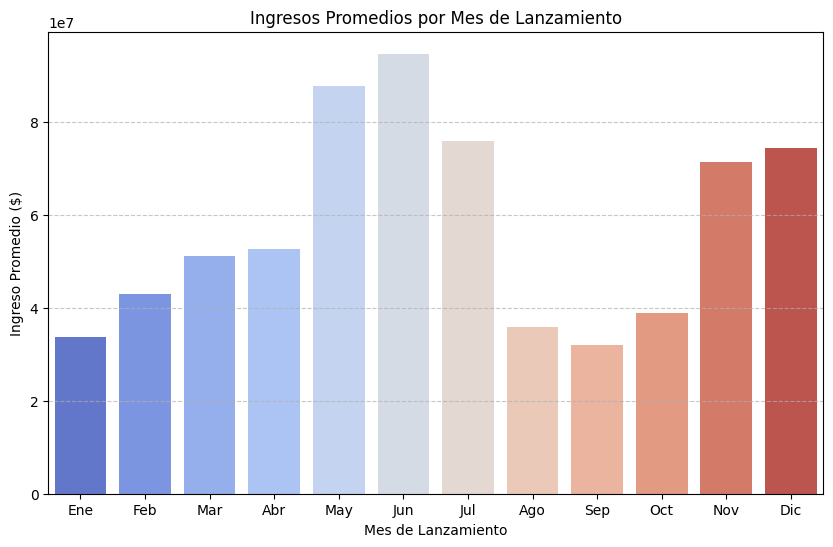

In [186]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseMonth'] = df['releaseDate'].dt.month

monthly_revenue = df.groupby('releaseMonth')['revenue'].mean().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='coolwarm')
plt.xlabel("Mes de Lanzamiento")
plt.ylabel("Ingreso Promedio ($)")
plt.title("Ingresos Promedios por Mes de Lanzamiento")
plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **16. ¿En qué meses se han visto los lanzamientos con mejores ingresos? ¿Cuántas películas, en promedio, se han lanzado por mes?**

El mes con mayores ingresos promedio fue 6 con ingresos de $94,747,108.23.


C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2548109160.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette="coolwarm")


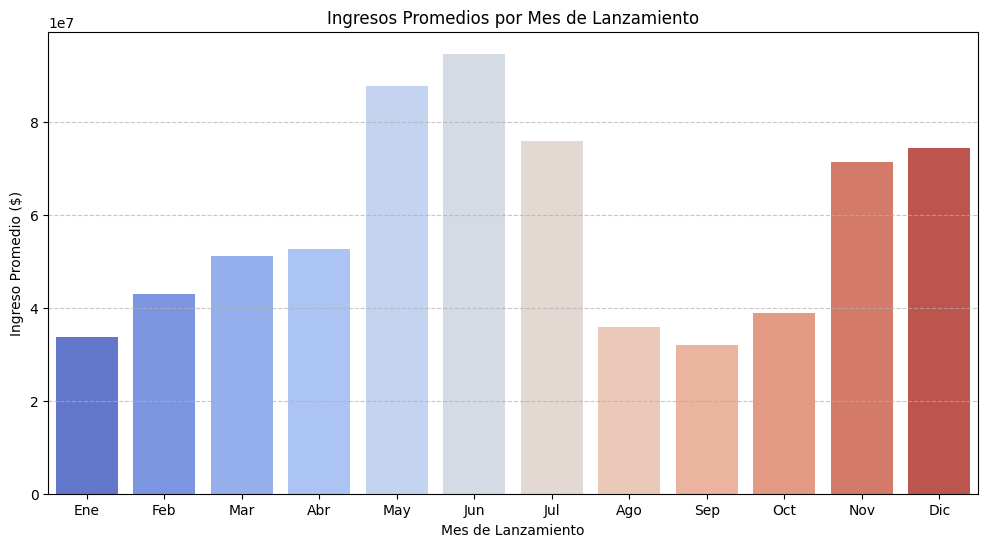

En promedio, se han lanzado 833.33 películas por mes.


C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2548109160.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_count.index, y=monthly_count.values, palette="Blues_r")


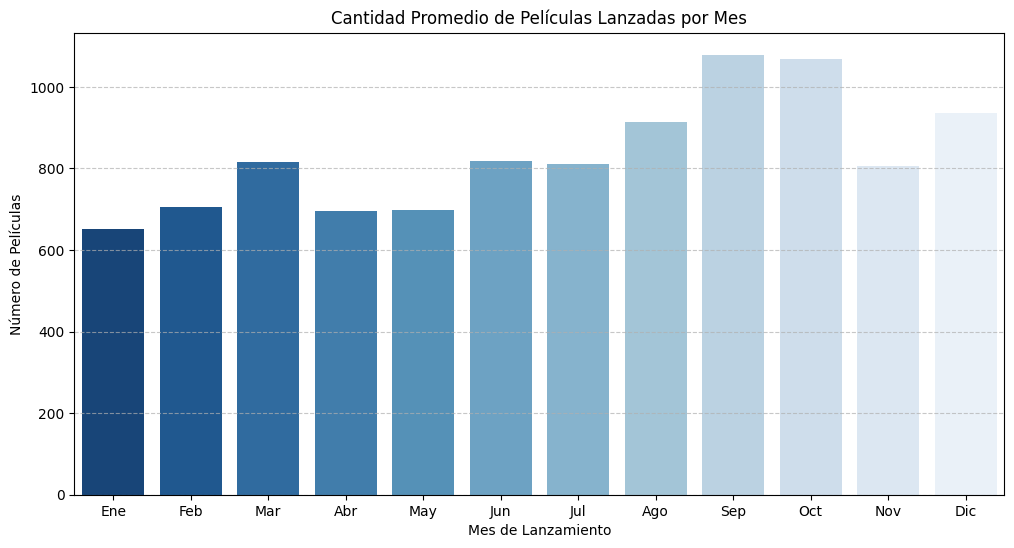

In [187]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseMonth'] = df['releaseDate'].dt.month

monthly_revenue = df.groupby('releaseMonth')['revenue'].mean().sort_values(ascending=False)
monthly_count = df['releaseMonth'].value_counts().sort_index()
best_revenue_month = monthly_revenue.idxmax()
best_revenue_value = monthly_revenue.max()
avg_movies_per_month = monthly_count.mean()

print(f"El mes con mayores ingresos promedio fue {best_revenue_month} con ingresos de ${best_revenue_value:,.2f}.")
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette="coolwarm")
plt.xlabel("Mes de Lanzamiento")
plt.ylabel("Ingreso Promedio ($)")
plt.title("Ingresos Promedios por Mes de Lanzamiento")
plt.xticks(ticks=range(12), labels=["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print(f"En promedio, se han lanzado {avg_movies_per_month:.2f} películas por mes.")
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_count.index, y=monthly_count.values, palette="Blues_r")
plt.xlabel("Mes de Lanzamiento")
plt.ylabel("Número de Películas")
plt.title("Cantidad Promedio de Películas Lanzadas por Mes")
plt.xticks(ticks=range(12), labels=["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **17. ¿Cómo se correlacionan las calificaciones con el éxito comercial?**

,Métrica,Coeficiente de Correlación,P-Value
0,Pearson,0.167763,2.816342e-34
1,Spearman,0.120105,3.052400e-18


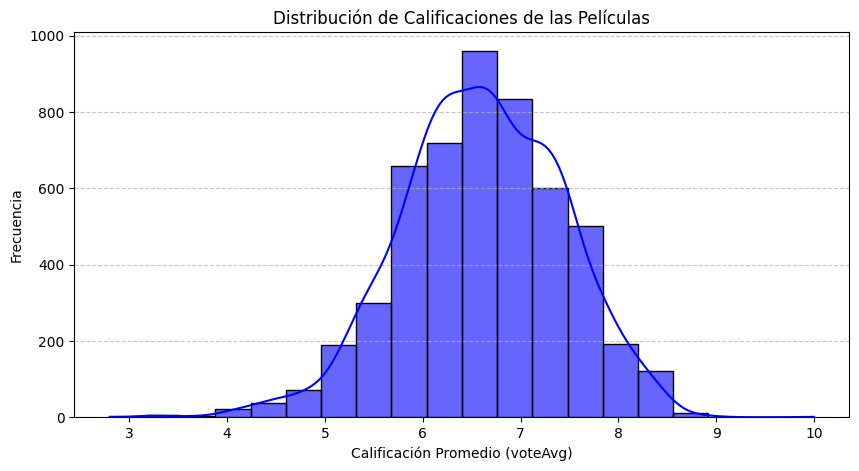

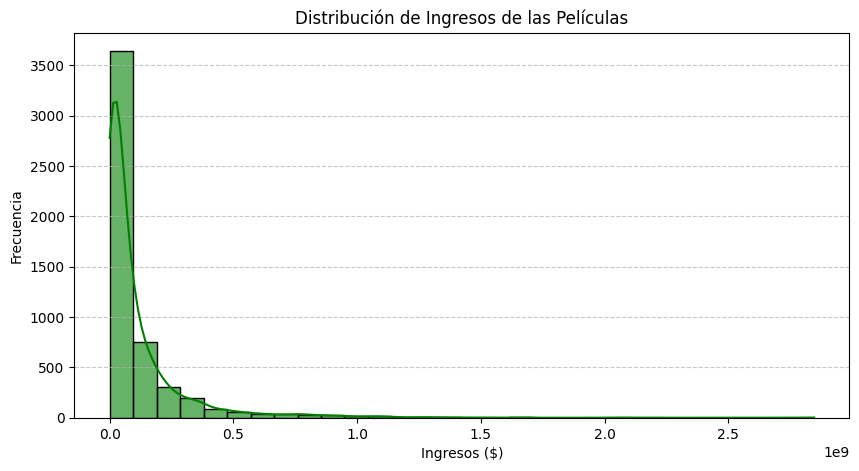

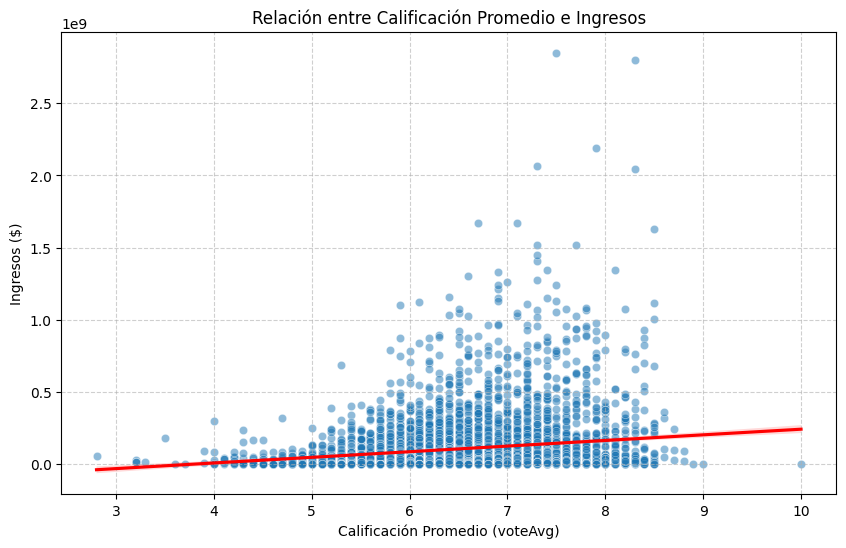

In [188]:
df['voteAvg'] = pd.to_numeric(df['voteAvg'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df_filtered = df[(df['voteAvg'].notna()) & (df['revenue'] > 0)]
pearson_corr, pearson_p = pearsonr(df_filtered['voteAvg'], df_filtered['revenue'])
spearman_corr, spearman_p = spearmanr(df_filtered['voteAvg'], df_filtered['revenue'])

correlation_df = pd.DataFrame({
    "Métrica": ["Pearson", "Spearman"],
    "Coeficiente de Correlación": [pearson_corr, spearman_corr],
    "P-Value": [pearson_p, spearman_p]
})
display(correlation_df)

plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['voteAvg'], bins=20, kde=True, color='blue', alpha=0.6)
plt.xlabel("Calificación Promedio (voteAvg)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Calificaciones de las Películas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['revenue'], bins=30, kde=True, color='green', alpha=0.6)
plt.xlabel("Ingresos ($)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ingresos de las Películas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_filtered['voteAvg'], y=df_filtered['revenue'], alpha=0.5)
sns.regplot(x=df_filtered['voteAvg'], y=df_filtered['revenue'], scatter=False, color='red')
plt.xlabel("Calificación Promedio (voteAvg)")
plt.ylabel("Ingresos ($)")
plt.title("Relación entre Calificación Promedio e Ingresos")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **18. ¿Qué estrategias de marketing, como videos promocionales o páginas oficiales, generan mejores resultados?**

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2000016637.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_video'] = df.get('video', pd.Series([False] * len(df))).fillna(False).astype(int)
C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2000016637.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sin Página Web', 'Con Página Web'], y=homepage_revenue_avg.values, palette="coolwarm")


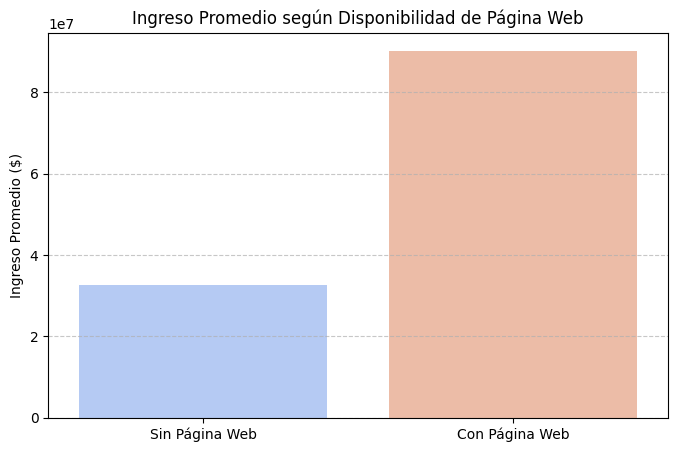

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2000016637.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sin Video', 'Con Video'], y=video_revenue_avg.values, palette="coolwarm")


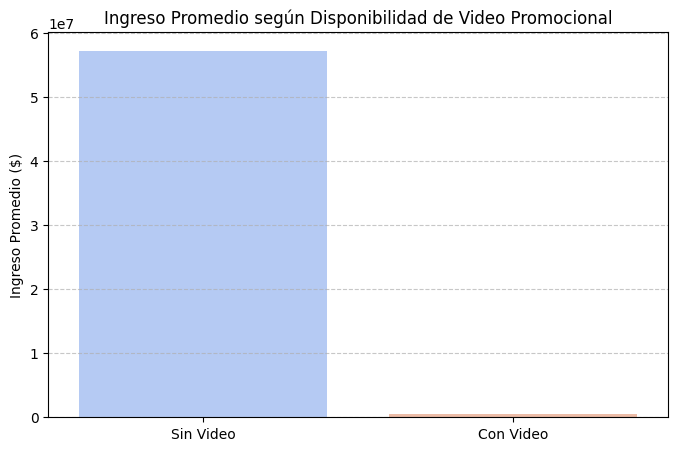

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2000016637.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sin Página Web', 'Con Página Web'], y=homepage_vote_avg.values, palette="coolwarm")


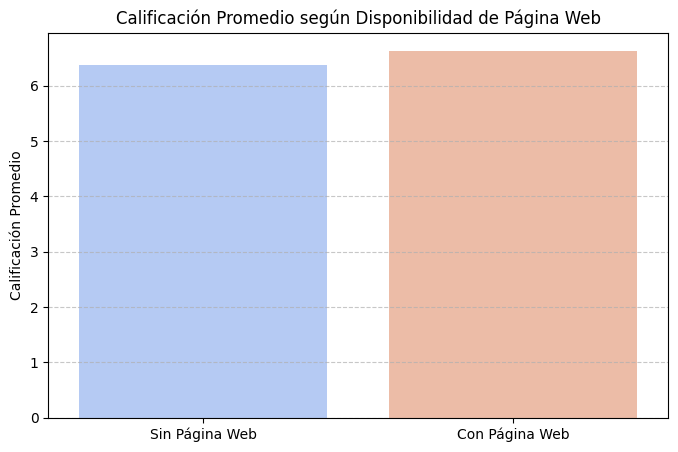

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\2000016637.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sin Video', 'Con Video'], y=video_vote_avg.values, palette="coolwarm")


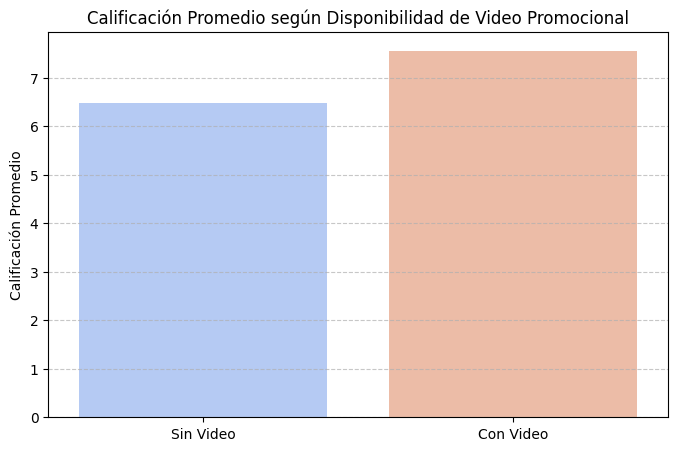

In [203]:

df['has_homepage'] = df.get('homePage', pd.Series([None] * len(df))).notnull().astype(int)
df['has_video'] = df.get('video', pd.Series([False] * len(df))).fillna(False).astype(int)


homepage_revenue_avg = df.groupby('has_homepage')['revenue'].mean()
video_revenue_avg = df.groupby('has_video')['revenue'].mean()
homepage_vote_avg = df.groupby('has_homepage')['voteAvg'].mean()
video_vote_avg = df.groupby('has_video')['voteAvg'].mean()


plt.figure(figsize=(8, 5))
sns.barplot(x=['Sin Página Web', 'Con Página Web'], y=homepage_revenue_avg.values, palette="coolwarm")
plt.ylabel("Ingreso Promedio ($)")
plt.title("Ingreso Promedio según Disponibilidad de Página Web")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(x=['Sin Video', 'Con Video'], y=video_revenue_avg.values, palette="coolwarm")
plt.ylabel("Ingreso Promedio ($)")
plt.title("Ingreso Promedio según Disponibilidad de Video Promocional")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(x=['Sin Página Web', 'Con Página Web'], y=homepage_vote_avg.values, palette="coolwarm")
plt.ylabel("Calificación Promedio")
plt.title("Calificación Promedio según Disponibilidad de Página Web")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(x=['Sin Video', 'Con Video'], y=video_vote_avg.values, palette="coolwarm")
plt.ylabel("Calificación Promedio")
plt.title("Calificación Promedio según Disponibilidad de Video Promocional")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## **19. ¿La popularidad del elenco está directamente correlacionada con el éxito de taquilla?**

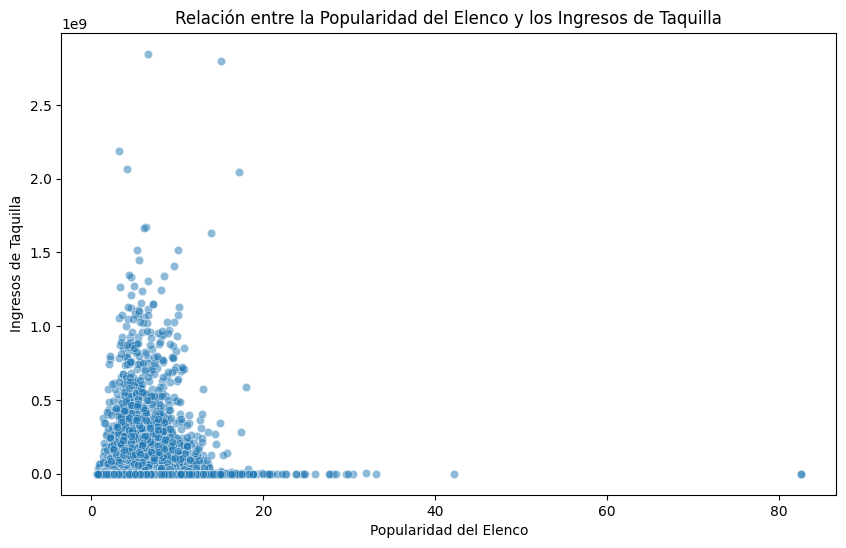

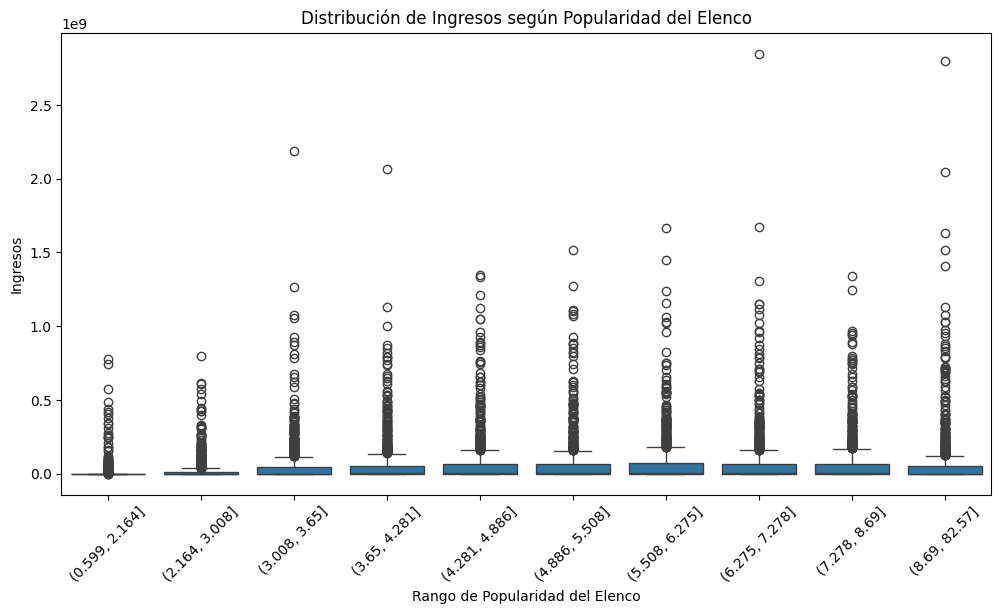

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\1781632737.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_income_per_bin = df.groupby('actorsPopularity_bins')['revenue'].median()


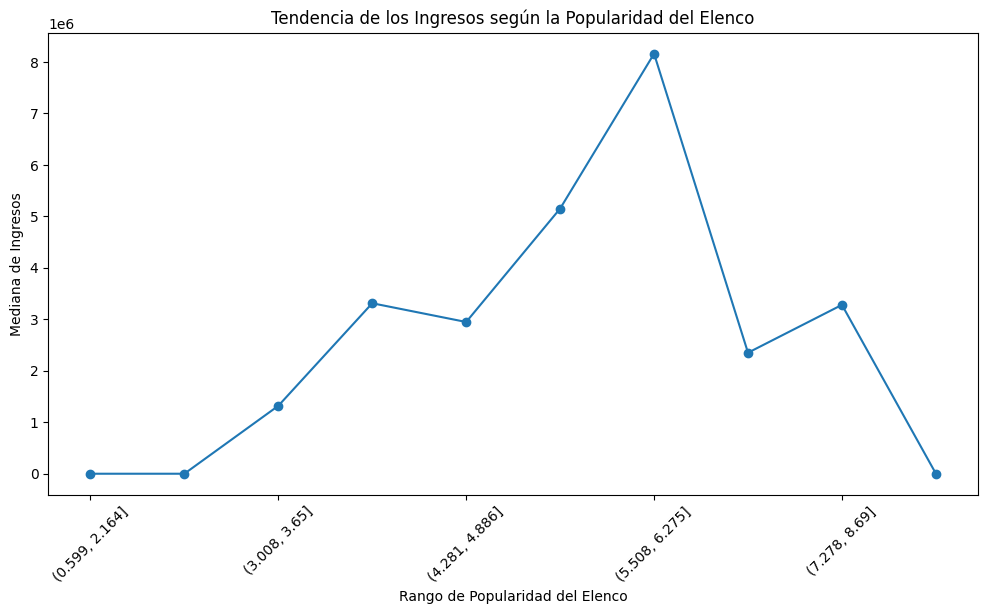

Coeficiente de correlación de Pearson: 0.0821
Valor p: 0.0000


In [190]:
df = df[['actorsPopularity', 'revenue']].dropna()

corr, p_value = pearsonr(df['actorsPopularity'], df['revenue'])

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['actorsPopularity'], y=df['revenue'], alpha=0.5)
plt.title("Relación entre la Popularidad del Elenco y los Ingresos de Taquilla")
plt.xlabel("Popularidad del Elenco")
plt.ylabel("Ingresos de Taquilla")
plt.show()

df['actorsPopularity_bins'] = pd.qcut(df['actorsPopularity'], q=10)
plt.figure(figsize=(12,6))
sns.boxplot(x=df['actorsPopularity_bins'], y=df['revenue'])
plt.xticks(rotation=45)
plt.title("Distribución de Ingresos según Popularidad del Elenco")
plt.xlabel("Rango de Popularidad del Elenco")
plt.ylabel("Ingresos")
plt.show()

median_income_per_bin = df.groupby('actorsPopularity_bins')['revenue'].median()

plt.figure(figsize=(12,6))
median_income_per_bin.plot(marker='o', linestyle='-')
plt.title("Tendencia de los Ingresos según la Popularidad del Elenco")
plt.xlabel("Rango de Popularidad del Elenco")
plt.ylabel("Mediana de Ingresos")
plt.xticks(rotation=45)
plt.show()

print(f"Coeficiente de correlación de Pearson: {corr:.4f}")
print(f"Valor p: {p_value:.4f}")

## **20. ¿Cuál es la relación entre el número de géneros de una película y sus ingresos?**

In [191]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df = df[df['revenue'] > 0]  

df['genresAmount'] = df['genres'].apply(lambda x: len(x.split('|')) if pd.notna(x) else 0)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['genresAmount'], y=df['revenue'], alpha=0.5)
plt.xlabel("Número de Géneros")
plt.ylabel("Ingresos")
plt.title("Relación entre el Número de Géneros y los Ingresos de las Películas")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['genresAmount'], y=df['revenue'])
plt.xlabel("Número de Géneros")
plt.ylabel("Ingresos")
plt.title("Distribución de Ingresos según el Número de Géneros")
plt.show()

genre_revenue_median = df.groupby('genresAmount')['revenue'].median()

plt.figure(figsize=(10, 6))
plt.plot(genre_revenue_median.index, genre_revenue_median.values, marker='o', linestyle='-')
plt.xlabel("Número de Géneros")
plt.ylabel("Mediana de Ingresos")
plt.title("Tendencia de los Ingresos según el Número de Géneros")
plt.grid(True)
plt.show()

pearson_corr, pearson_p = stats.pearsonr(df['genresAmount'], df['revenue'])

print(f"Coeficiente de correlación de Pearson: {pearson_corr:.4f}")
print(f"Valor p: {pearson_p:.4f}")


KeyError: 'genres'

## **21. ¿Cuál es la relación entre la popularidad de una película y su número de votos? ¿Las películas más populares tienen más votos?**

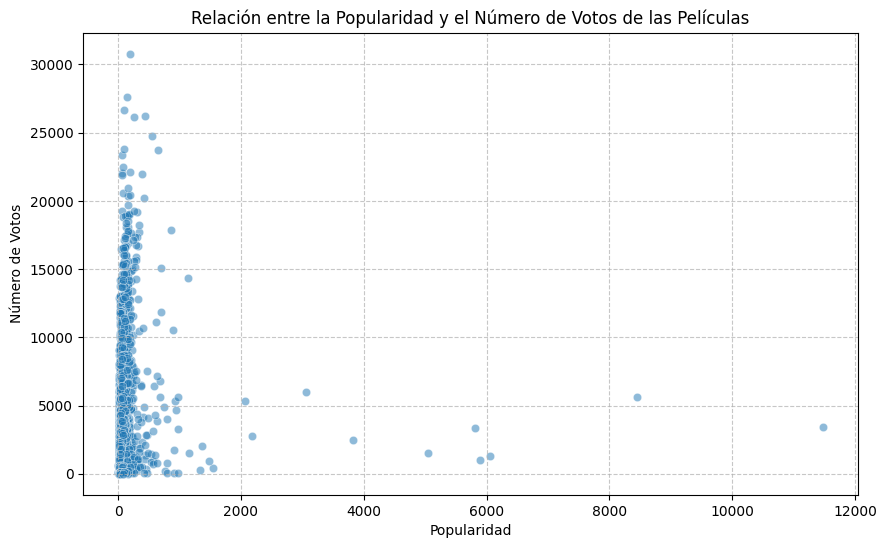

Coeficiente de correlación de Pearson: 0.1128
Valor p: 0.0000


C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\3421129259.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity_vote_trend = df.groupby(pd.qcut(df['popularity'], q=20))['voteCount'].median()


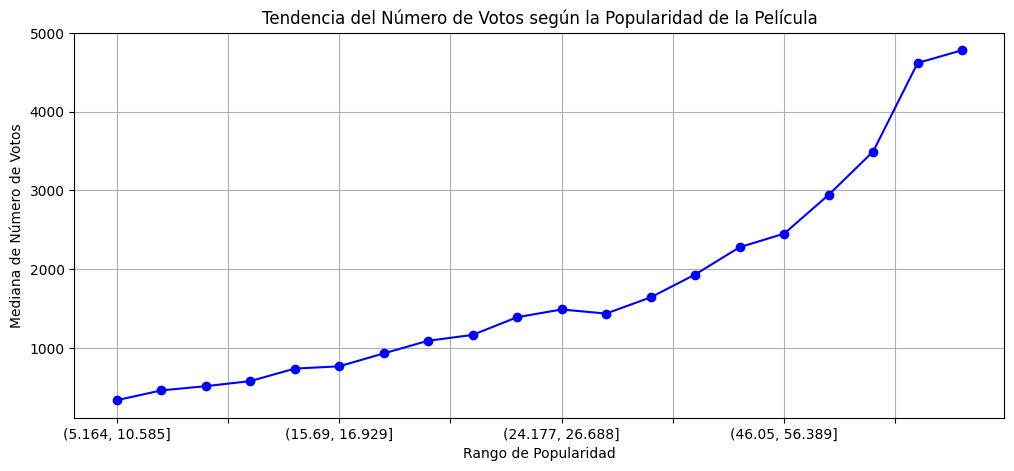

In [149]:
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
df['voteCount'] = pd.to_numeric(df['voteCount'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['popularity'], y=df['voteCount'], alpha=0.5)
plt.xlabel("Popularidad")
plt.ylabel("Número de Votos")
plt.title("Relación entre la Popularidad y el Número de Votos de las Películas")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

pearson_corr, pearson_p = pearsonr(df['popularity'].dropna(), df['voteCount'].dropna())

print(f"Coeficiente de correlación de Pearson: {pearson_corr:.4f}")
print(f"Valor p: {pearson_p:.4f}")

popularity_vote_trend = df.groupby(pd.qcut(df['popularity'], q=20))['voteCount'].median()

plt.figure(figsize=(12, 5))
popularity_vote_trend.plot(kind='line', marker='o', color='blue')
plt.xlabel("Rango de Popularidad")
plt.ylabel("Mediana de Número de Votos")
plt.title("Tendencia del Número de Votos según la Popularidad de la Película")
plt.grid()
plt.show()


## **22. ¿Existe una relación entre la duración de una película y su calificación promedio?**

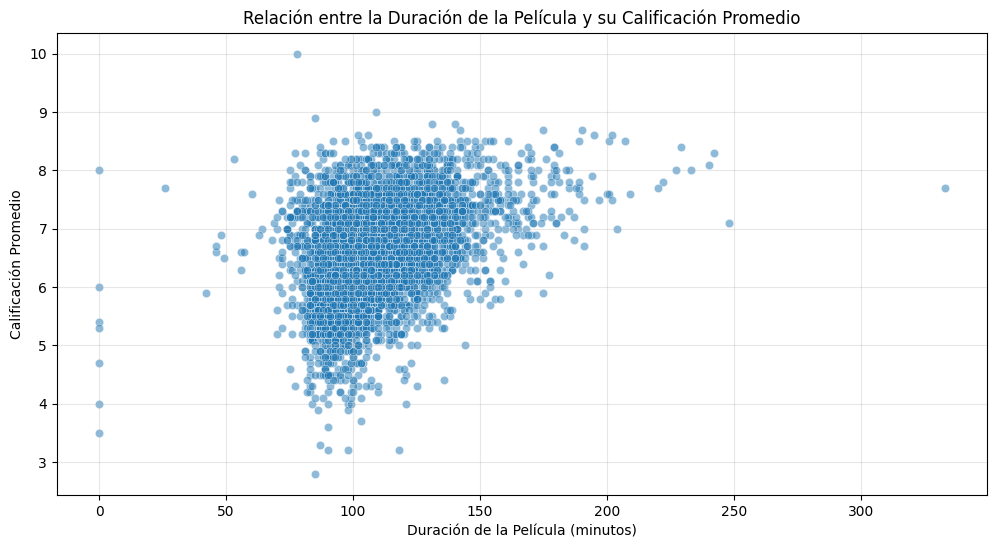

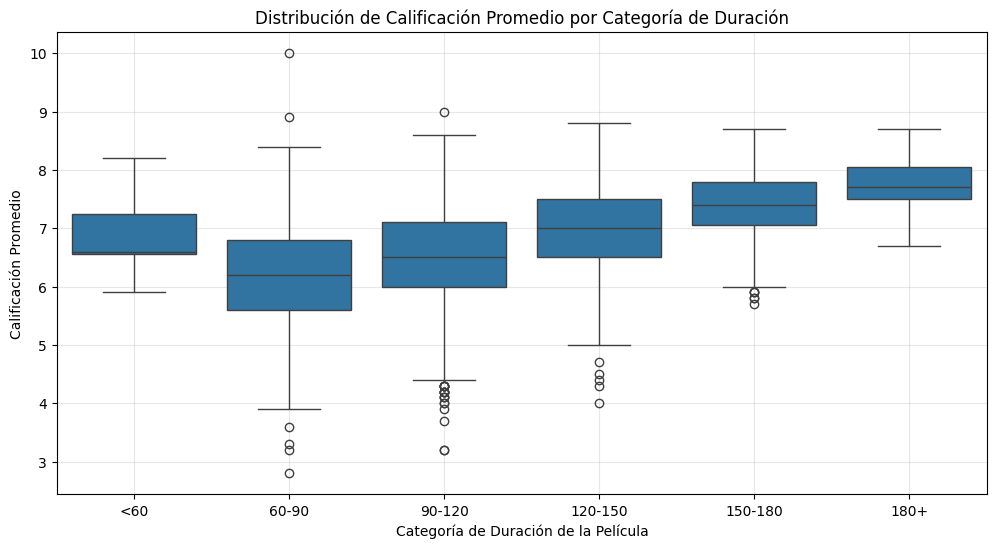

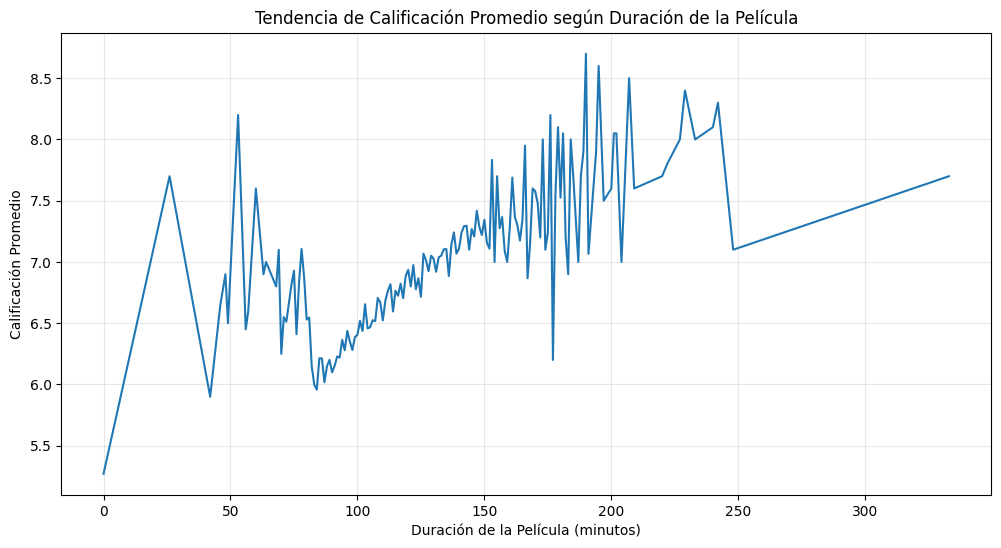

In [ ]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['voteAvg'] = pd.to_numeric(df['voteAvg'], errors='coerce')

df_filtered = df.dropna(subset=['runtime', 'voteAvg'])

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_filtered['runtime'], y=df_filtered['voteAvg'], alpha=0.5)
plt.xlabel("Duración de la Película (minutos)")
plt.ylabel("Calificación Promedio")
plt.title("Relación entre la Duración de la Película y su Calificación Promedio")
plt.grid(alpha=0.3)
plt.show()

df_filtered['runtime_category'] = pd.cut(df_filtered['runtime'], bins=[0, 60, 90, 120, 150, 180, 300], 
                                         labels=["<60", "60-90", "90-120", "120-150", "150-180", "180+"])

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_filtered['runtime_category'], y=df_filtered['voteAvg'])
plt.xlabel("Categoría de Duración de la Película")
plt.ylabel("Calificación Promedio")
plt.title("Distribución de Calificación Promedio por Categoría de Duración")
plt.grid(alpha=0.3)
plt.show()

runtime_avg_rating = df_filtered.groupby('runtime')['voteAvg'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=runtime_avg_rating.index, y=runtime_avg_rating.values)
plt.xlabel("Duración de la Película (minutos)")
plt.ylabel("Calificación Promedio")
plt.title("Tendencia de Calificación Promedio según Duración de la Película")
plt.grid(alpha=0.3)
plt.show()


## **23. ¿Qué productoras han lanzado más películas y cuál es su éxito promedio en ingresos?**

Las 10 productoras con más películas y su éxito promedio en ingresos:


,Películas,Ingreso Promedio
productionCompany,,
Warner Bros. Pictures,427,1.724597e+08
Universal Pictures,407,1.493042e+08
Columbia Pictures,319,1.558521e+08
Paramount,296,1.591523e+08
20th Century Fox,286,1.876944e+08
Walt Disney Pictures,167,3.031033e+08
New Line Cinema,159,1.515820e+08
Metro-Goldwyn-Mayer,138,1.243469e+08
Canal+,121,6.139558e+07


C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\655938247.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productions.index, y=top_productions.values, palette="Blues")


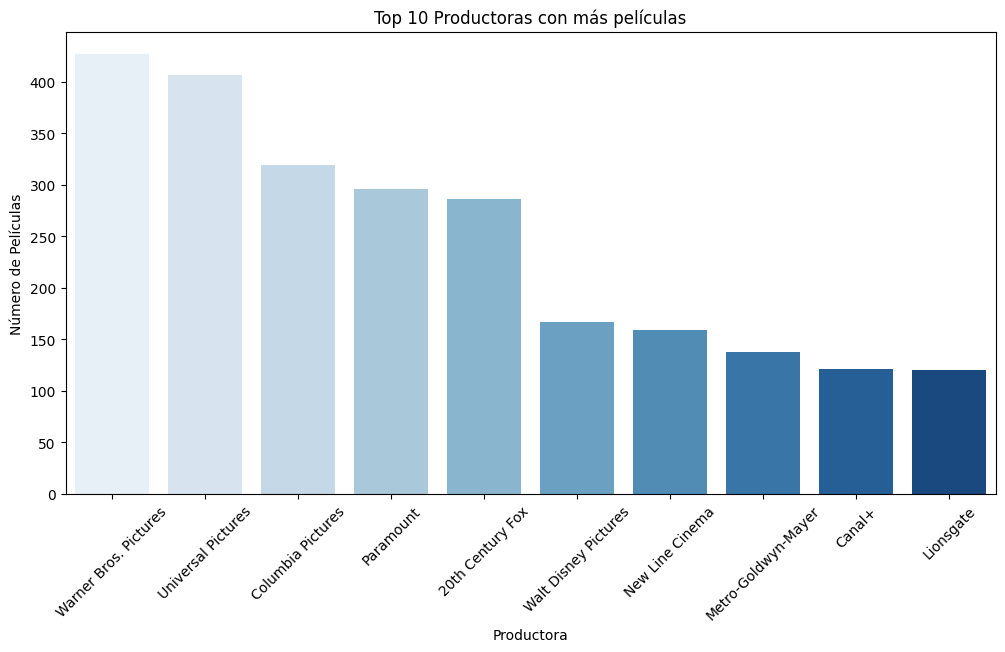

C:\Users\sofia\AppData\Local\Temp\ipykernel_11788\655938247.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productions_revenue.index, y=top_productions_revenue.values, palette="Greens")


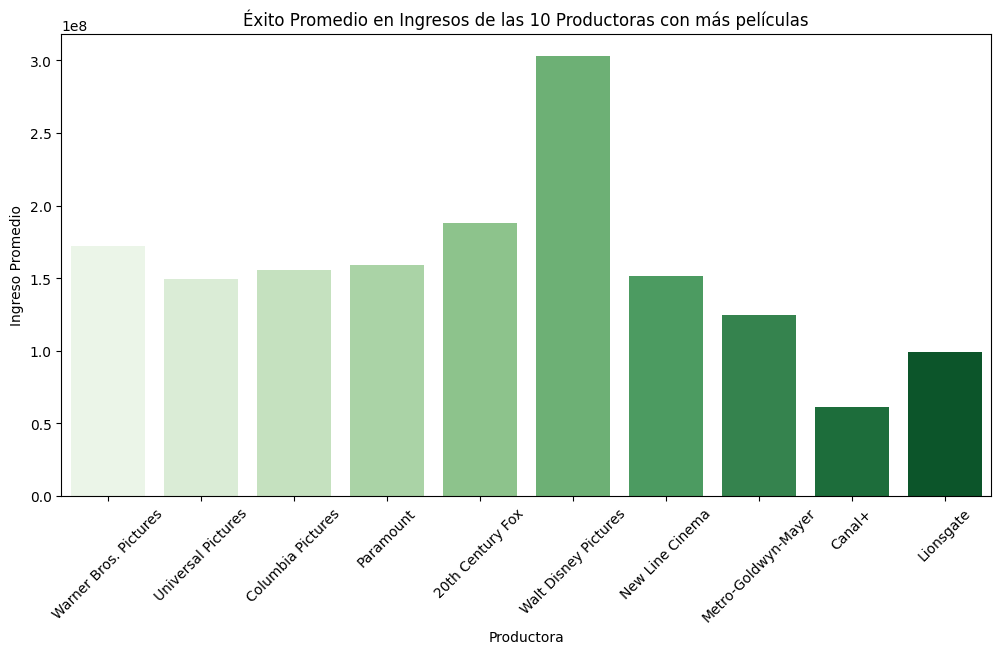

In [ ]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

production_counts = df['productionCompany'].dropna().str.split('|').explode().value_counts()

top_productions = production_counts.head(10)

production_revenue = df[['productionCompany', 'revenue']].dropna()
production_revenue = production_revenue.assign(productionCompany=production_revenue['productionCompany'].str.split('|')).explode('productionCompany')

average_revenue = production_revenue.groupby('productionCompany')['revenue'].mean().sort_values(ascending=False)

top_productions_revenue = average_revenue.loc[top_productions.index]

print("Las 10 productoras con más películas y su éxito promedio en ingresos:")
display(pd.DataFrame({'Películas': top_productions, 'Ingreso Promedio': top_productions_revenue}))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_productions.index, y=top_productions.values, palette="Blues")
plt.xticks(rotation=45)
plt.xlabel("Productora")
plt.ylabel("Número de Películas")
plt.title("Top 10 Productoras con más películas")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=top_productions_revenue.index, y=top_productions_revenue.values, palette="Greens")
plt.xticks(rotation=45)
plt.xlabel("Productora")
plt.ylabel("Ingreso Promedio")
plt.title("Éxito Promedio en Ingresos de las 10 Productoras con más películas")
plt.show()


## **24. ¿Las películas con página web tienen mejores ingresos y calificaciones?**

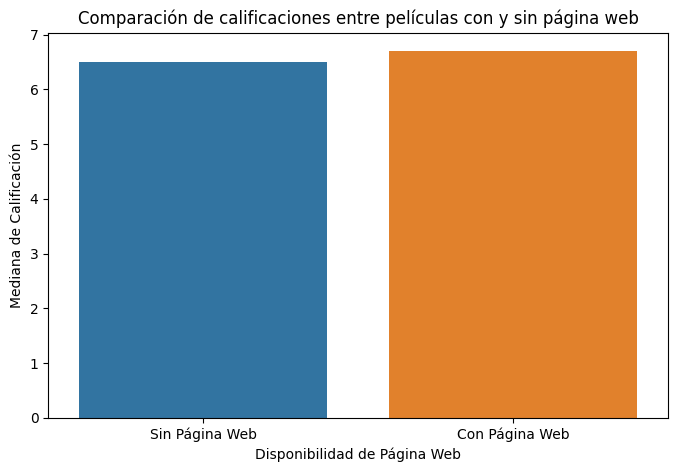

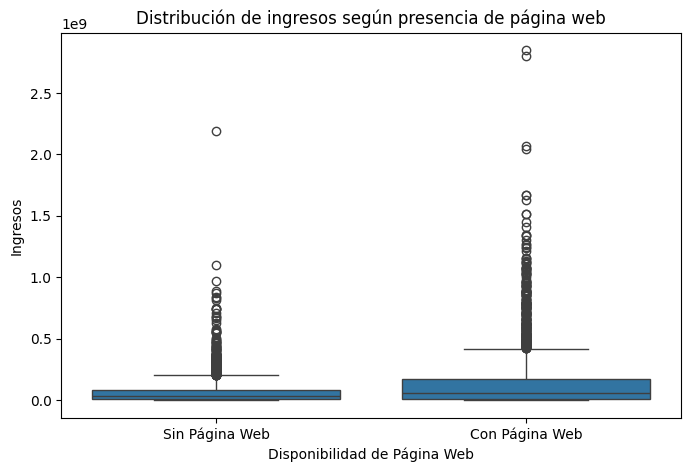

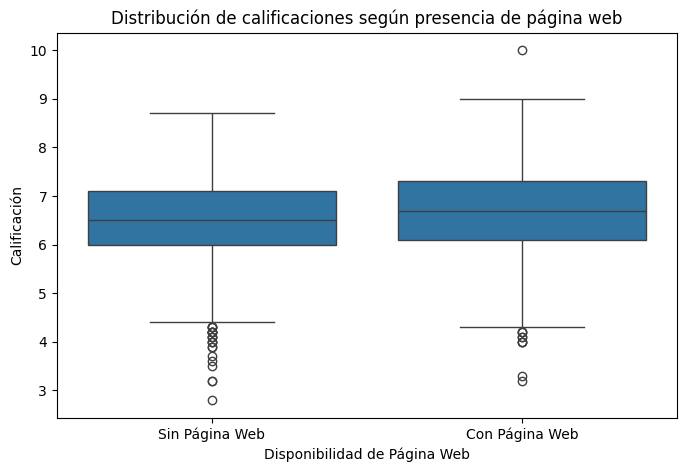

In [152]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['voteAvg'] = pd.to_numeric(df['voteAvg'], errors='coerce')

df['has_homepage'] = df['homePage'].notna().astype(int)

df_filtered = df.dropna(subset=['revenue'])

income_comparison = df_filtered.groupby('has_homepage')['revenue'].median()

rating_comparison = df.groupby('has_homepage')['voteAvg'].median()

# Verificar si ambas categorías tienen datos
if income_comparison.isnull().sum() > 0:
    print("Advertencia: Algunas categorías no tienen datos de ingresos.")

plt.figure(figsize=(8, 5))
sns.barplot(x=rating_comparison.index, y=rating_comparison.values, hue=rating_comparison.index, legend=False)
plt.xticks(ticks=[0, 1], labels=["Sin Página Web", "Con Página Web"])
plt.ylabel("Mediana de Calificación")
plt.xlabel("Disponibilidad de Página Web")
plt.title("Comparación de calificaciones entre películas con y sin página web")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_filtered['has_homepage'], y=df_filtered['revenue'])
plt.xticks(ticks=[0, 1], labels=["Sin Página Web", "Con Página Web"])
plt.ylabel("Ingresos")
plt.xlabel("Disponibilidad de Página Web")
plt.title("Distribución de ingresos según presencia de página web")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['has_homepage'], y=df['voteAvg'])
plt.xticks(ticks=[0, 1], labels=["Sin Página Web", "Con Página Web"])
plt.ylabel("Calificación")
plt.xlabel("Disponibilidad de Página Web")
plt.title("Distribución de calificaciones según presencia de página web")
plt.show()

## **25. ¿Las películas de ciertos idiomas tienen una mayor rentabilidad en términos de ingresos respecto al presupuesto?**

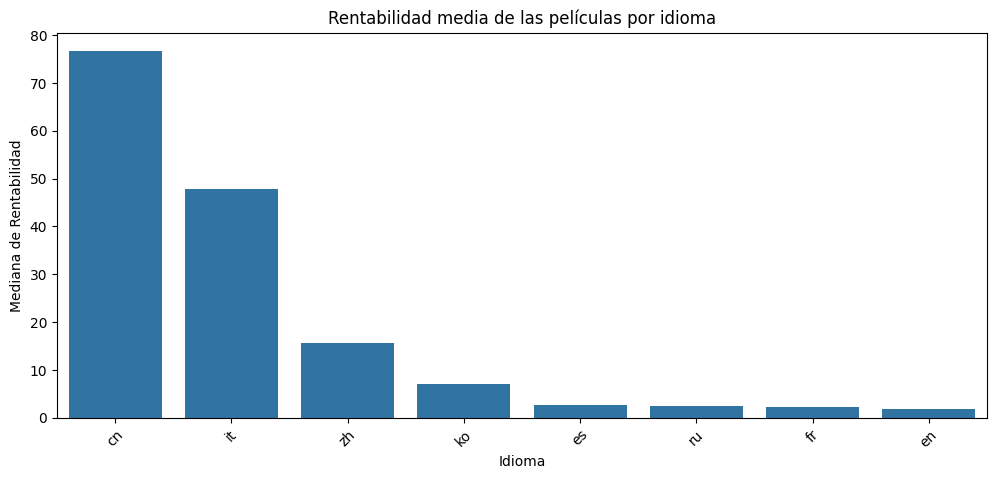

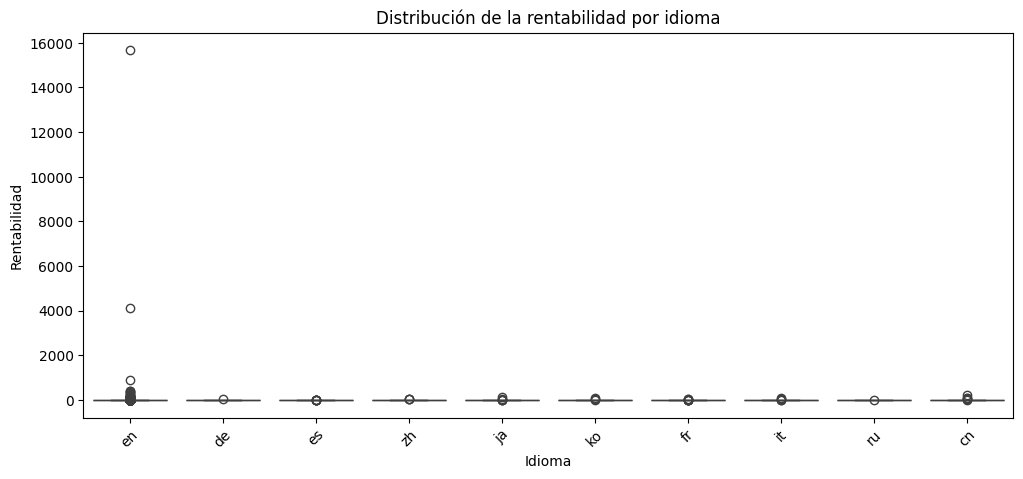

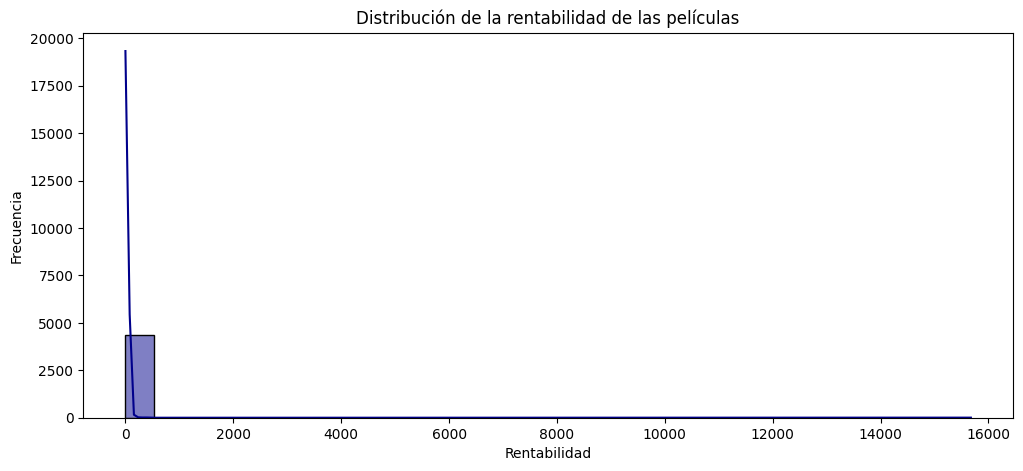

In [153]:
df['profit_margin'] = (df['revenue'] - df['budget']) / df['budget']

top_languages = df['originalLanguage'].value_counts().index[:10]
language_profit = df[df['originalLanguage'].isin(top_languages)].groupby('originalLanguage')['profit_margin'].median().sort_values(ascending=False)

language_profit = language_profit.replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(12, 5))
sns.barplot(x=language_profit.index, y=language_profit.values)
plt.xticks(rotation=45)
plt.xlabel("Idioma")
plt.ylabel("Mediana de Rentabilidad")
plt.title("Rentabilidad media de las películas por idioma")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=df[df['originalLanguage'].isin(top_languages)]['originalLanguage'], y=df[df['originalLanguage'].isin(top_languages)]['profit_margin'])
plt.xticks(rotation=45)
plt.xlabel("Idioma")
plt.ylabel("Rentabilidad")
plt.title("Distribución de la rentabilidad por idioma")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['profit_margin'].dropna(), bins=30, kde=True, color='darkblue')
plt.xlabel("Rentabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la rentabilidad de las películas")
plt.show()


## **Fin :)**